# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import the classification report
from sklearn.metrics import classification_report

# Import the f1 score
from sklearn.metrics import f1_score

# Import train test split
from sklearn.model_selection import train_test_split

# Import KFold
from sklearn.model_selection import KFold

# Import pickle
import pickle

# Import t-SNE and UMAP
from sklearn.manifold import TSNE
import umap

# Import random
import random
random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import the datasets

In [2]:
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'

In [3]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_X_train_combined_SMOTE.pkl', 'rb') as f:
    convabuse_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_X_test_combined_SMOTE.pkl', 'rb') as f:
    convabuse_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_y_train_combined_SMOTE.pkl', 'rb') as f:
    convabuse_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_y_test_combined_SMOTE.pkl', 'rb') as f:
    convabuse_y_test = pickle.load(f)

In [4]:
pd.Series(convabuse_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [5]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_agent_X_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_y_test = pickle.load(f)

In [6]:
pd.Series(convabuse_prev_agent_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [7]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_user_X_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_y_test = pickle.load(f)

In [8]:
pd.Series(convabuse_prev_user_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [9]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_agent_X_train_SMOTE.pkl', 'rb') as e:
    convabuse_agent_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_agent_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_agent_y_train_SMOTE.pkl', 'rb') as g:
    convabuse_agent_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_agent_y_test_SMOTE.pkl', 'rb') as h:
    convabuse_agent_y_test = pickle.load(h)

In [10]:
pd.Series(convabuse_agent_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [11]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_user_X_train_SMOTE.pkl', 'rb') as e:
    convabuse_user_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_user_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_user_y_train_SMOTE.pkl', 'rb') as g:
    convabuse_user_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_user_y_test_SMOTE.pkl', 'rb') as h:
    convabuse_user_y_test = pickle.load(h)

In [12]:
pd.Series(convabuse_user_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [13]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_target_X_train_SMOTE.pkl', 'rb') as e:
    dynamically_generated_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_target_X_test_SMOTE.pkl', 'rb') as f:
    dynamically_generated_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_target_y_train_SMOTE.pkl', 'rb') as g:
    dynamically_generated_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_target_y_test_SMOTE.pkl', 'rb') as h:
    dynamically_generated_hate_speech_target_y_test = pickle.load(h)

In [14]:
pd.Series(dynamically_generated_hate_speech_target_y_train).value_counts()

,count
0,24757
1,24757


In [15]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_label_X_train_SMOTE.pkl', 'rb') as e:
    dynamically_generated_hate_speech_label_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_label_X_test_SMOTE.pkl', 'rb') as f:
    dynamically_generated_hate_speech_label_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_label_y_train_SMOTE.pkl', 'rb') as g:
    dynamically_generated_hate_speech_label_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_label_y_test_SMOTE.pkl', 'rb') as h:
    dynamically_generated_hate_speech_label_y_test = pickle.load(h)

In [16]:
pd.Series(dynamically_generated_hate_speech_label_y_train).value_counts()

,count
1.0,17574
0.0,17574


In [17]:
# Open the pickled embeddings
with open(f'{pickle_path}mlma_hate_speech_target_X_train_SMOTE.pkl', 'rb') as e:
    mlma_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}mlma_hate_speech_target_X_test_SMOTE.pkl', 'rb') as f:
    mlma_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}mlma_hate_speech_target_y_train_SMOTE.pkl', 'rb') as g:
    mlma_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}mlma_hate_speech_target_y_test_SMOTE.pkl', 'rb') as h:
    mlma_hate_speech_target_y_test = pickle.load(h)

In [18]:
pd.Series(mlma_hate_speech_target_y_train).value_counts()

,count
2,6115
1,6115
0,6115
3,6115


In [19]:
regularizers = ["l1", "l2"]

In [20]:
solvers = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]

In [21]:
l1_ratio_list = [0.5]

In [22]:
logistic_regression_model_results = []

In [23]:
logistic_regression_TSNE = {}

In [24]:
logistic_regression_UMAP = {}

## Convabuse Logistic Regression

In [25]:
def logistic_regression_modeling(X_train, X_test, y_train, y_test, target, dataset):
  results_list = []

  # Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Convabuse dataset
  for regularizer in regularizers:
    for solver in solvers:
      if regularizer == "l1" and solver not in ["liblinear", "saga"]:
        continue
      # Add condition for elasticnet and solver saga in the first loop
      if regularizer == "elasticnet" and solver != "saga":
          continue
      logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
      logistic_regression.fit(X_train, y_train)
      # Predict the target variable for the test set
      y_pred = logistic_regression.predict(X_test)

      # Calculate the accuracy of the model
      accuracy = accuracy_score(y_test, y_pred)
      f1 = f1_score(y_test, y_pred, average='weighted') # Weighted average due to multiclass
      results_list.append((dataset, regularizer, solver, accuracy, f1, 0))
      print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {accuracy}, F1-score: {f1}")

  for ratio in l1_ratio_list:
      logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
      logistic_regression.fit(X_train, y_train)
      # Predict the target variable for the test set
      y_pred = logistic_regression.predict(X_test)

      # Calculate the accuracy of the model
      accuracy = accuracy_score(y_test, y_pred)
      f1 = f1_score(y_test, y_pred, average='weighted')
      results_list.append((dataset, "elasticnet", "saga", accuracy, f1, ratio))
      print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {accuracy}, F1-score: {f1}")

  # Convert the results list into a dataframe
  results = pd.DataFrame(results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])

  best_model_params = results.loc[results["Accuracy"].idxmax()]
  best_model_params

  # Use the best parameters to create a new best model
  if best_model_params["Regularizer"] == "elasticnet":
      best_model = LogisticRegression(penalty=best_model_params["Regularizer"], solver=best_model_params["Solver"], l1_ratio=best_model_params["Ratio"], random_state=42)
  else:
      best_model = LogisticRegression(penalty=best_model_params["Regularizer"], solver=best_model_params["Solver"], random_state=42)

  best_model.fit(X_train, y_train)

  # Predict the target variable for the test set
  y_pred = best_model.predict(X_test)

  # Calculate the accuracy of the model
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average='weighted')

  # Calculate and plot the confusion matrix
  from sklearn.metrics import confusion_matrix
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='hot')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()

  # Get the coefficients for each feature
  feature_importances = np.sum(best_model.coef_, axis=0)

  # Sort the feature importances
  feature_columns_sorted = np.argsort(feature_importances)[::-1]
  feature_importances_sorted = feature_importances[feature_columns_sorted]
  top_10_features = feature_columns_sorted[:10][::-1]
  top_10_feature_importances = feature_importances_sorted[:10][::-1]

  # Create a list of column names (assuming they are indexed from 0 to n-1)
  # This handles both pandas DataFrames and NumPy arrays
  if isinstance(X_train, pd.DataFrame):
    column_names = X_train.columns
  else:
    column_names = [i for i in range(X_train.shape[1])] # Use integer indices

  # Convert to a dictionary
  feature_importances_data = {}
  for feature, importance in zip(column_names, feature_importances):
    feature_importances_data[feature] = importance
  feature_importances_sorted_dict = {}
  for feature, importance in zip(column_names, feature_importances_sorted):
    feature_importances_sorted_dict[feature] = importance

  # Plot the top 10 feature importances as a horizontal bar chart
  plt.figure(figsize=(10, 6))
  # Use the actual integer indices of the top 10 features as labels
  sns.barplot(x=top_10_feature_importances, y=top_10_features.astype(str), palette='hot') # Convert to string for y-axis labels
  plt.xlabel("Importance")
  plt.ylabel("Feature Index")
  plt.title(f"Top 10 Feature Importances - {dataset}")
  plt.show()

  # Create a dictionary using the top 10 features and top 10 feature importances
  top_10_feature_importances_data = {feature: importance for feature, importance in zip(top_10_features, top_10_feature_importances)}

  # Print the dictionary
  print("Top 10 Feature Importances")
  print(top_10_feature_importances_data)

  print("Linear Coefficients")
  print(feature_importances_data)

  logistic_regression_model_results.append((dataset, best_model_params, accuracy, f1, 0.0, feature_importances_data, top_10_feature_importances_data))

  print(f"Regularizer: {best_model_params['Regularizer']}, Solver: {best_model_params['Solver']}, Accuracy: {accuracy}, F1-score: {f1}")

  X_train_df = pd.DataFrame(X_train)
  y_train_series = pd.Series(y_train)
  X_test_df = pd.DataFrame(X_test)

  # Get the best correlated feature with the target variable
  best_correlated_feature = X_train_df.corrwith(y_train_series).abs().idxmax()
  print(f"Best correlated feature: {best_correlated_feature}")

  # Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
  sns.histplot(y_pred, kde=True, label='Predicted')
  plt.xlabel('Prediction')
  plt.ylabel('Frequency')
  plt.title(f'Histogram of Predictions - {dataset}')
  plt.show()

  # Plot the actual values
  sns.histplot(y_test, kde=True, label='Actual')
  plt.xlabel('Actual Value')
  plt.ylabel('Frequency')
  plt.title(f'Histogram of Actual Values - {dataset}')
  plt.show()

  # Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
  sns.scatterplot(x=X_test_df[best_correlated_feature], y=y_pred, hue=y_test, palette='hot')
  plt.show()

  # Use t-sne and color code by the target variable

  # Reduce dimensionality of test data using t-SNE
  tsne_test = TSNE(n_components=2, random_state=42)
  X_test_tsne = tsne_test.fit_transform(X_test)

  # Create a scatter plot
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='hot', alpha=0.6)
  plt.title(f't-SNE Visualization of {dataset} User Dataset')
  plt.xlabel('t-SNE Component 1')
  plt.ylabel('t-SNE Component 2')
  plt.colorbar(scatter, label=f'{target}')
  plt.show()

  # Calculate if predictions are correct (within a tolerance)
  tolerance = 0.5  # Define a tolerance for what is considered "correct"
  correct_predictions = np.abs(y_pred - y_test) <= tolerance

  # Create a scatter plot, coloring by correctness
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6)
  plt.title(f't-SNE Visualization of {dataset} Test Data: Correct vs Incorrect Predictions')
  plt.xlabel('t-SNE Component 1')
  plt.ylabel('t-SNE Component 2')
  cbar = plt.colorbar(scatter, ticks=[0, 1])
  cbar.ax.set_yticklabels(['Incorrect', 'Correct'])
  plt.show()

  # Use UMAP and color code by the target variable
  # Reduce dimensionality using UMAP
  reducer = umap.UMAP(random_state=42)
  X_test_umap = reducer.fit_transform(X_test)

  # Create a scatter plot
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='hot', alpha=0.6)
  plt.title(f'UMAP Visualization of {dataset} User Dataset')
  plt.xlabel('UMAP Component 1')
  plt.ylabel('UMAP Component 2')
  plt.colorbar(scatter, label=f'{target}')
  plt.show()

  logistic_regression_TSNE[dataset] = X_test_tsne
  logistic_regression_UMAP[dataset] = X_test_umap

  return results

Regularizer: l1, Solver: liblinear, Accuracy: 0.6399046104928457, F1-score: 0.7029215490501577
Regularizer: l1, Solver: saga, Accuracy: 0.6351351351351351, F1-score: 0.6999440834915412
Regularizer: l2, Solver: lbfgs, Accuracy: 0.6383147853736089, F1-score: 0.7021608231664387
Regularizer: l2, Solver: liblinear, Accuracy: 0.643879173290938, F1-score: 0.7052040374691624
Regularizer: l2, Solver: newton-cg, Accuracy: 0.6406995230524642, F1-score: 0.7038515563212289
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.6414944356120826, F1-score: 0.7043684830746588
Regularizer: l2, Solver: sag, Accuracy: 0.6414944356120826, F1-score: 0.7043684830746588
Regularizer: l2, Solver: saga, Accuracy: 0.6414944356120826, F1-score: 0.7043684830746588
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.6379173290937997, F1-score: 0.702099224968783


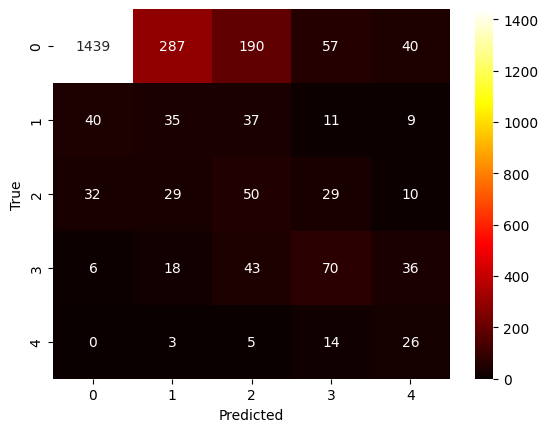

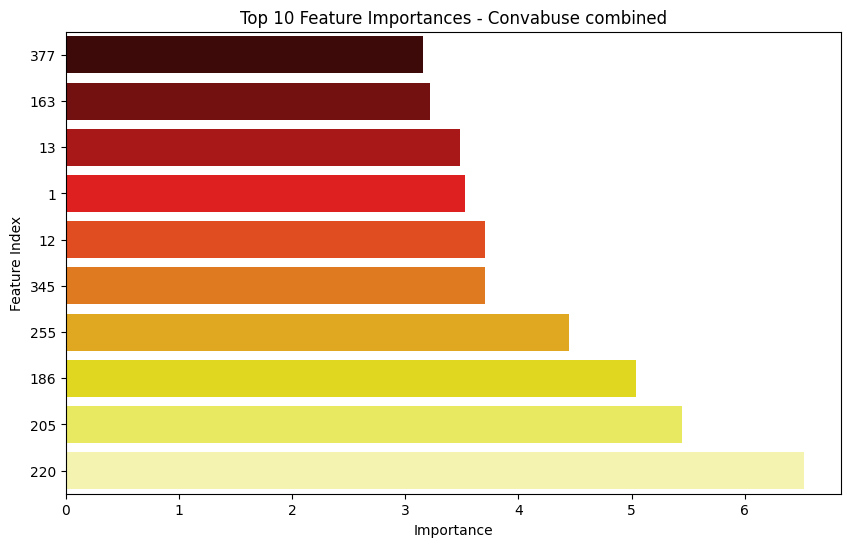

Top 10 Feature Importances
{np.int64(377): np.float64(3.159550474305021), np.int64(163): np.float64(3.2189173198686065), np.int64(13): np.float64(3.48670051233141), np.int64(1): np.float64(3.5262021446676504), np.int64(12): np.float64(3.702961068102992), np.int64(345): np.float64(3.707720755407909), np.int64(255): np.float64(4.445682760706715), np.int64(186): np.float64(5.0353287599560215), np.int64(205): np.float64(5.4422400829061806), np.int64(220): np.float64(6.524182764394968)}
Linear Coefficients
{0: np.float64(-1.1665910251555753), 1: np.float64(3.5262021446676504), 2: np.float64(1.3331076944467006), 3: np.float64(-1.7284678389722576), 4: np.float64(0.6738177302654534), 5: np.float64(0.46911763961467723), 6: np.float64(2.4967575463955867), 7: np.float64(-1.2646194694069248), 8: np.float64(2.113153218995343), 9: np.float64(-2.6514455942281843), 10: np.float64(0.2858632226875576), 11: np.float64(0.9234575536315102), 12: np.float64(3.702961068102992), 13: np.float64(3.48670051233141

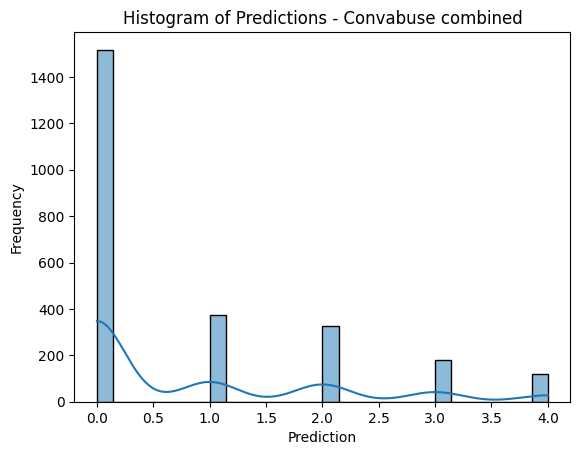

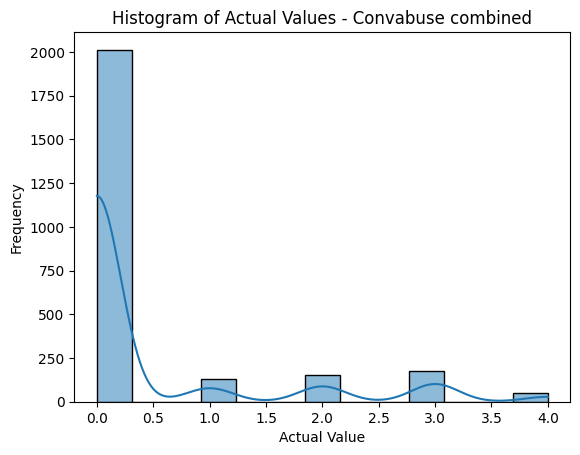

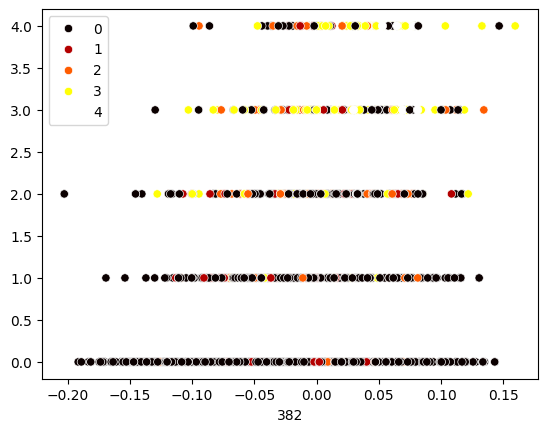

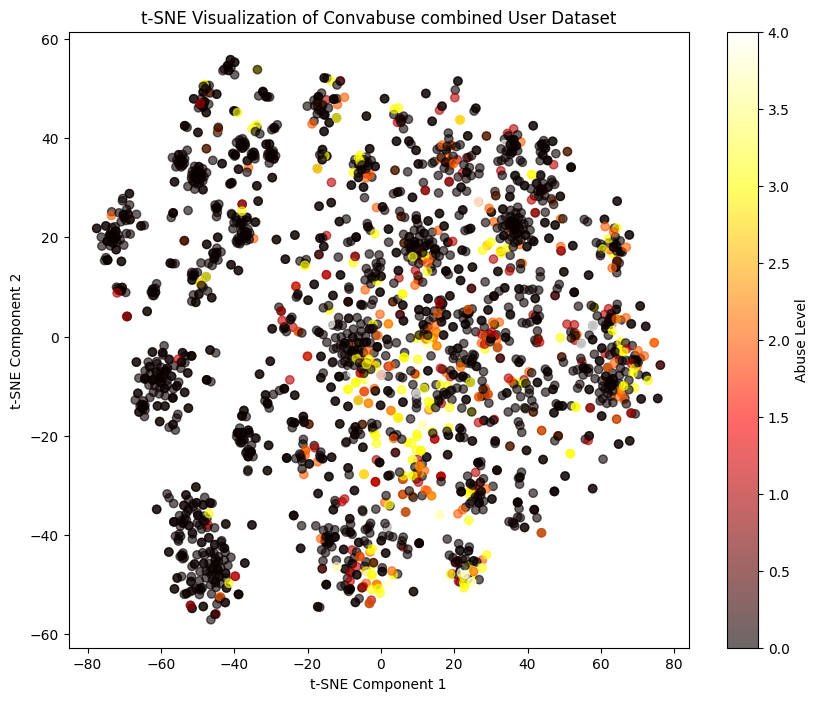

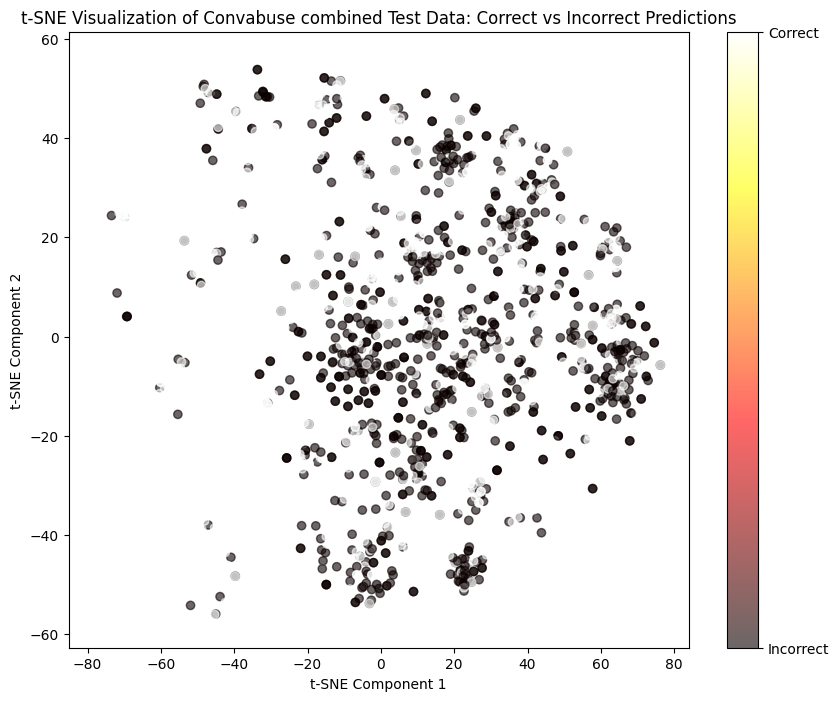

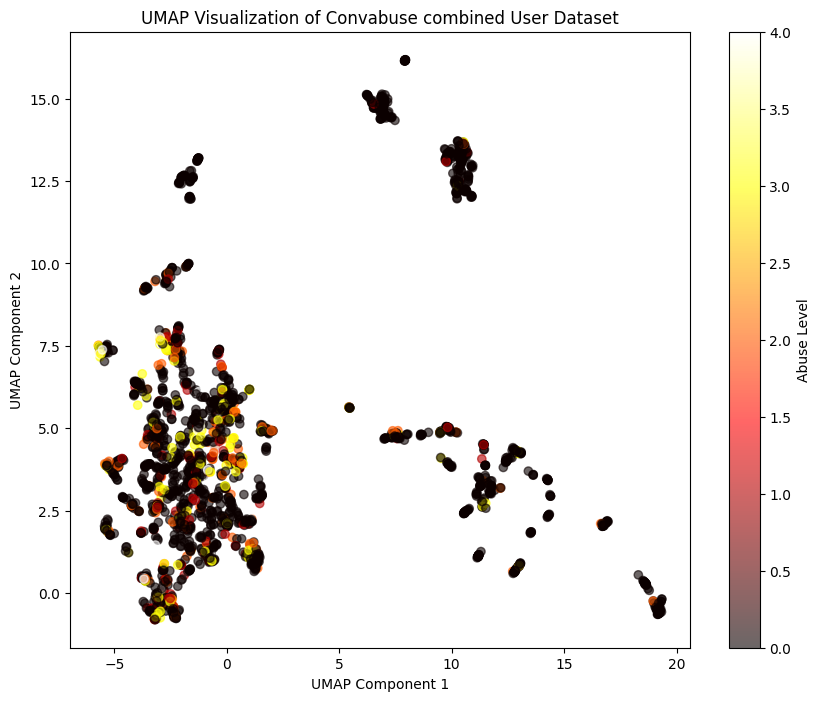

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse combined,l1,liblinear,0.639905,0.702922,0.0
1,Convabuse combined,l1,saga,0.635135,0.699944,0.0
2,Convabuse combined,l2,lbfgs,0.638315,0.702161,0.0
3,Convabuse combined,l2,liblinear,0.643879,0.705204,0.0
4,Convabuse combined,l2,newton-cg,0.640700,0.703852,0.0
5,Convabuse combined,l2,newton-cholesky,0.641494,0.704368,0.0
6,Convabuse combined,l2,sag,0.641494,0.704368,0.0
7,Convabuse combined,l2,saga,0.641494,0.704368,0.0
8,Convabuse combined,elasticnet,saga,0.637917,0.702099,0.5


In [26]:
convabuse_combined_results_list = logistic_regression_modeling(convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test, "Abuse Level", "Convabuse combined")
convabuse_combined_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.4030206677265501, F1-score: 0.5014734303278136
Regularizer: l1, Solver: saga, Accuracy: 0.404610492845787, F1-score: 0.5016006025674037
Regularizer: l2, Solver: lbfgs, Accuracy: 0.39666136724960255, F1-score: 0.4955314064462901
Regularizer: l2, Solver: liblinear, Accuracy: 0.38672496025437203, F1-score: 0.48564557037038464
Regularizer: l2, Solver: newton-cg, Accuracy: 0.39109697933227344, F1-score: 0.4894366348929019
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.39109697933227344, F1-score: 0.4894366348929019
Regularizer: l2, Solver: sag, Accuracy: 0.39109697933227344, F1-score: 0.4894366348929019
Regularizer: l2, Solver: saga, Accuracy: 0.39109697933227344, F1-score: 0.4894366348929019
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.39228934817170114, F1-score: 0.4903370075127458


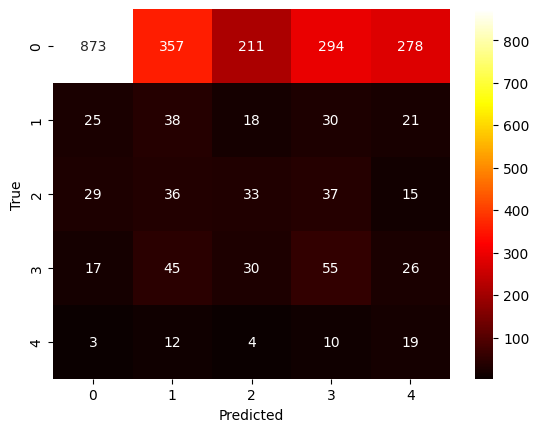

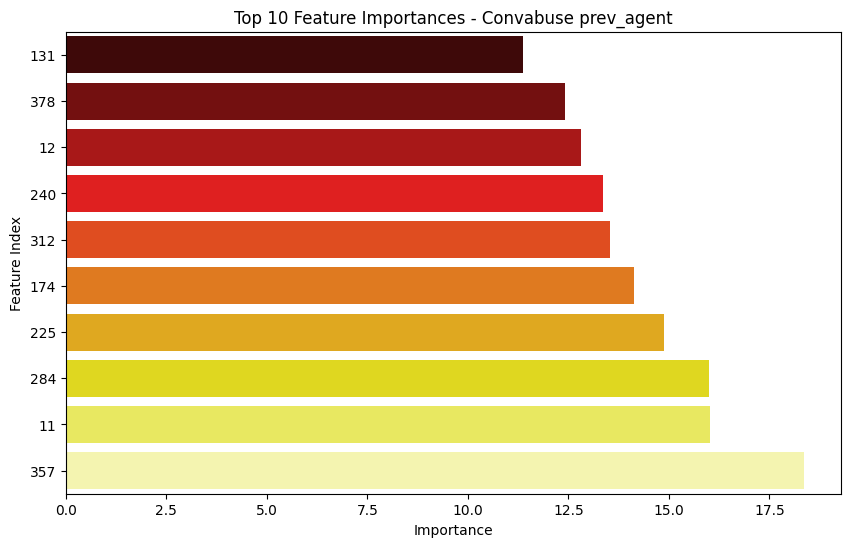

Top 10 Feature Importances
{np.int64(131): np.float32(11.366352), np.int64(378): np.float32(12.40703), np.int64(12): np.float32(12.820061), np.int64(240): np.float32(13.350879), np.int64(312): np.float32(13.536479), np.int64(174): np.float32(14.126421), np.int64(225): np.float32(14.876514), np.int64(284): np.float32(15.992982), np.int64(11): np.float32(16.017132), np.int64(357): np.float32(18.357569)}
Linear Coefficients
{0: np.float32(-0.8718583), 1: np.float32(6.904414), 2: np.float32(0.0), 3: np.float32(-1.2612977), 4: np.float32(0.9808035), 5: np.float32(0.99919415), 6: np.float32(0.030414581), 7: np.float32(2.9605258), 8: np.float32(4.194113), 9: np.float32(-1.9282374), 10: np.float32(0.0), 11: np.float32(16.017132), 12: np.float32(12.820061), 13: np.float32(-0.9769467), 14: np.float32(-4.6302137), 15: np.float32(0.0), 16: np.float32(-2.0656831), 17: np.float32(2.7865314), 18: np.float32(-6.3641243), 19: np.float32(-2.2884822), 20: np.float32(-1.0452511), 21: np.float32(3.000755),

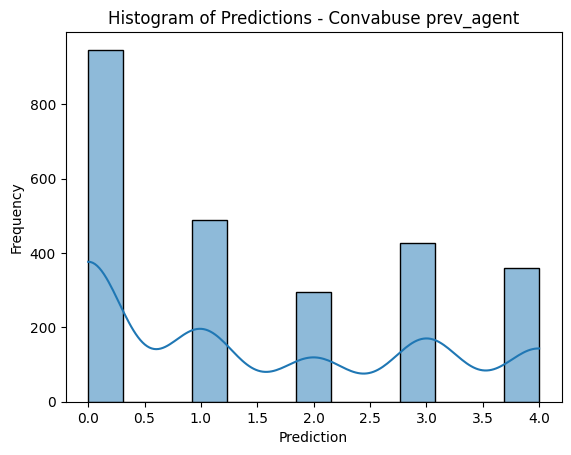

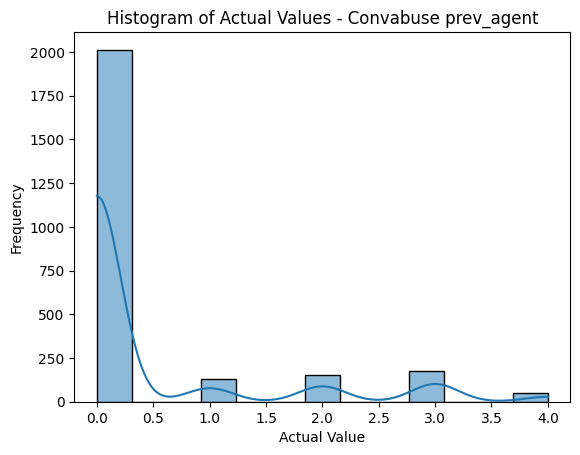

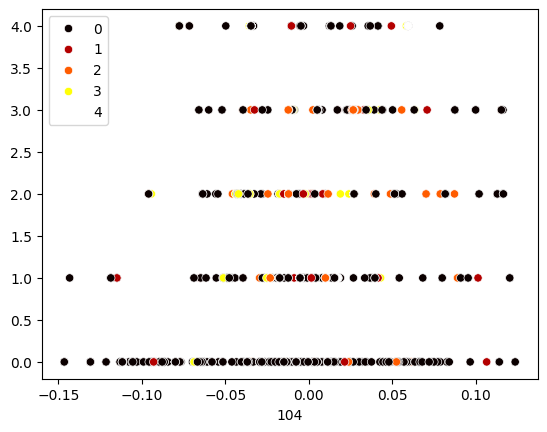

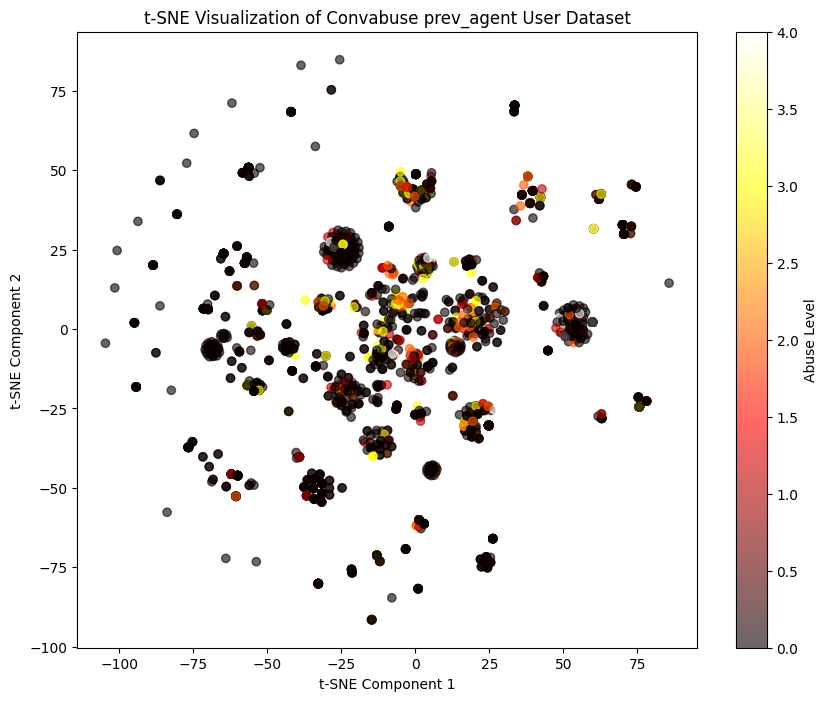

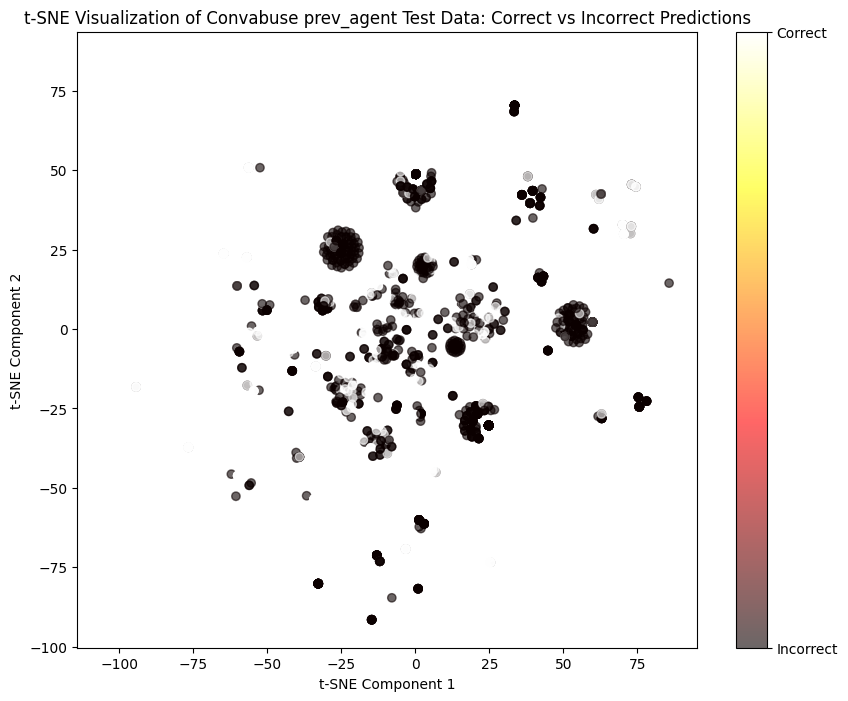

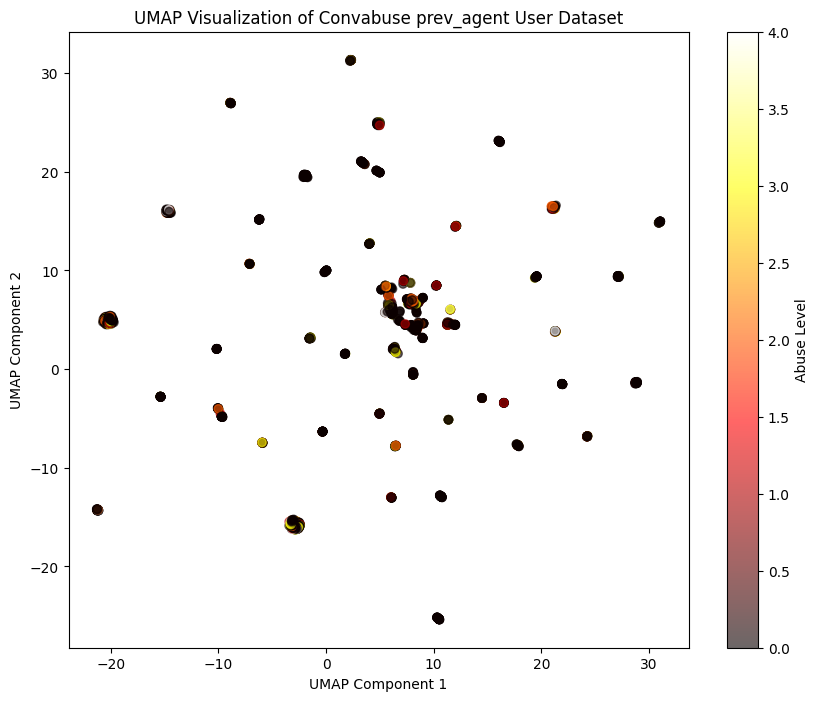

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse prev_agent,l1,liblinear,0.403021,0.501473,0.0
1,Convabuse prev_agent,l1,saga,0.404610,0.501601,0.0
2,Convabuse prev_agent,l2,lbfgs,0.396661,0.495531,0.0
3,Convabuse prev_agent,l2,liblinear,0.386725,0.485646,0.0
4,Convabuse prev_agent,l2,newton-cg,0.391097,0.489437,0.0
5,Convabuse prev_agent,l2,newton-cholesky,0.391097,0.489437,0.0
6,Convabuse prev_agent,l2,sag,0.391097,0.489437,0.0
7,Convabuse prev_agent,l2,saga,0.391097,0.489437,0.0
8,Convabuse prev_agent,elasticnet,saga,0.392289,0.490337,0.5


In [27]:
convabuse_prev_agent_results_list = logistic_regression_modeling(convabuse_prev_agent_X_train, convabuse_prev_agent_X_test, convabuse_prev_agent_y_train, convabuse_prev_agent_y_test, "Abuse Level", "Convabuse prev_agent")
convabuse_prev_agent_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.46502384737678853, F1-score: 0.5519542728051321
Regularizer: l1, Solver: saga, Accuracy: 0.465818759936407, F1-score: 0.5531152106114832
Regularizer: l2, Solver: lbfgs, Accuracy: 0.46621621621621623, F1-score: 0.5531119948773927
Regularizer: l2, Solver: liblinear, Accuracy: 0.4713831478537361, F1-score: 0.5573367408820227
Regularizer: l2, Solver: newton-cg, Accuracy: 0.4654213036565978, F1-score: 0.552402558128507
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.46740858505564387, F1-score: 0.5542166907682132
Regularizer: l2, Solver: sag, Accuracy: 0.46462639109697934, F1-score: 0.5516277579827427
Regularizer: l2, Solver: saga, Accuracy: 0.46740858505564387, F1-score: 0.5542166907682132
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.46621621621621623, F1-score: 0.5535879979522867


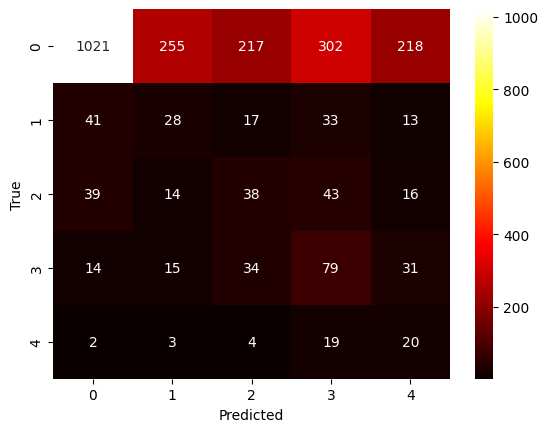

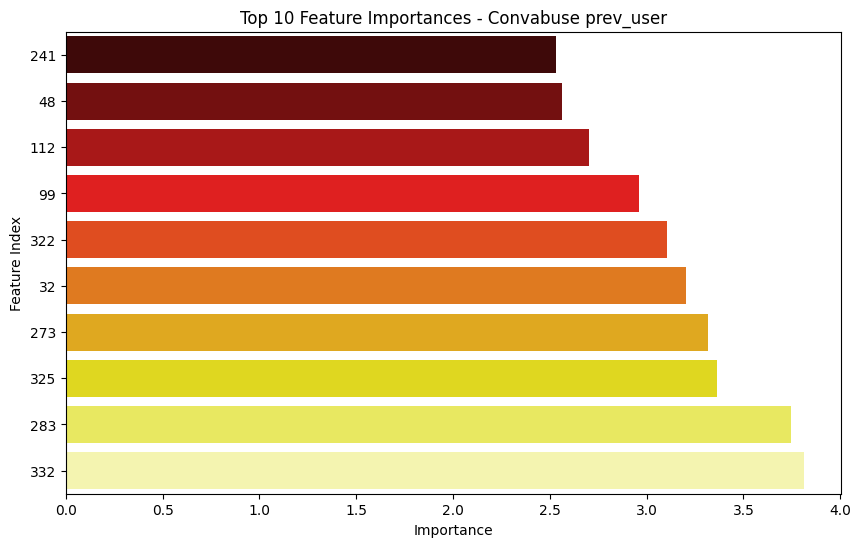

Top 10 Feature Importances
{np.int64(241): np.float64(2.532430360362501), np.int64(48): np.float64(2.562038247276439), np.int64(112): np.float64(2.7014282370522498), np.int64(99): np.float64(2.960488444365134), np.int64(322): np.float64(3.105681156854188), np.int64(32): np.float64(3.202369568123873), np.int64(273): np.float64(3.3156955771513874), np.int64(325): np.float64(3.363820063350149), np.int64(283): np.float64(3.746666882636811), np.int64(332): np.float64(3.8120580233695778)}
Linear Coefficients
{0: np.float64(-2.6109102025411186), 1: np.float64(0.6081769389837652), 2: np.float64(0.8400586056909694), 3: np.float64(1.4549743976617506), 4: np.float64(0.7061086564010002), 5: np.float64(-1.303439180966213), 6: np.float64(0.8328541311672564), 7: np.float64(1.4131379225962633), 8: np.float64(0.19806947077024528), 9: np.float64(-1.1602664561839662), 10: np.float64(-2.0081853531613603), 11: np.float64(0.16032357935037478), 12: np.float64(-0.6408680370836755), 13: np.float64(0.4625278273

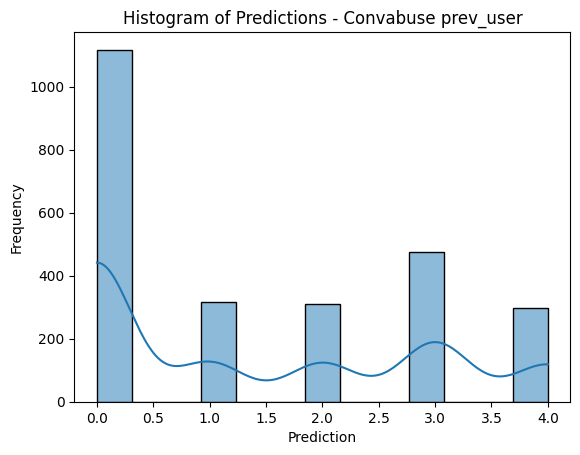

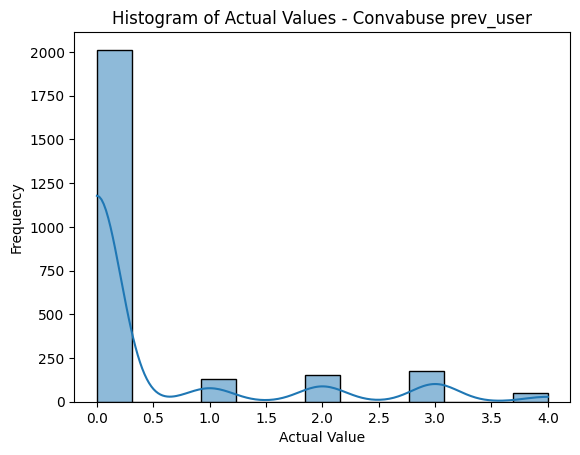

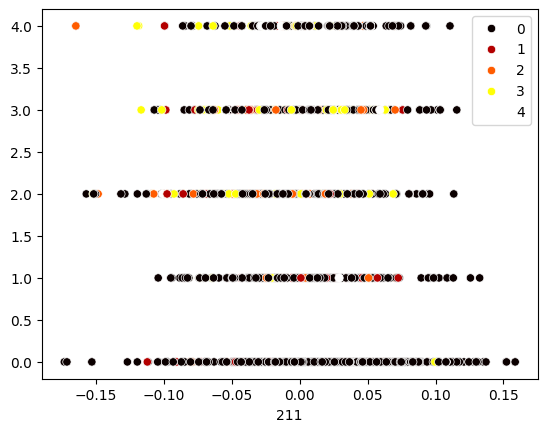

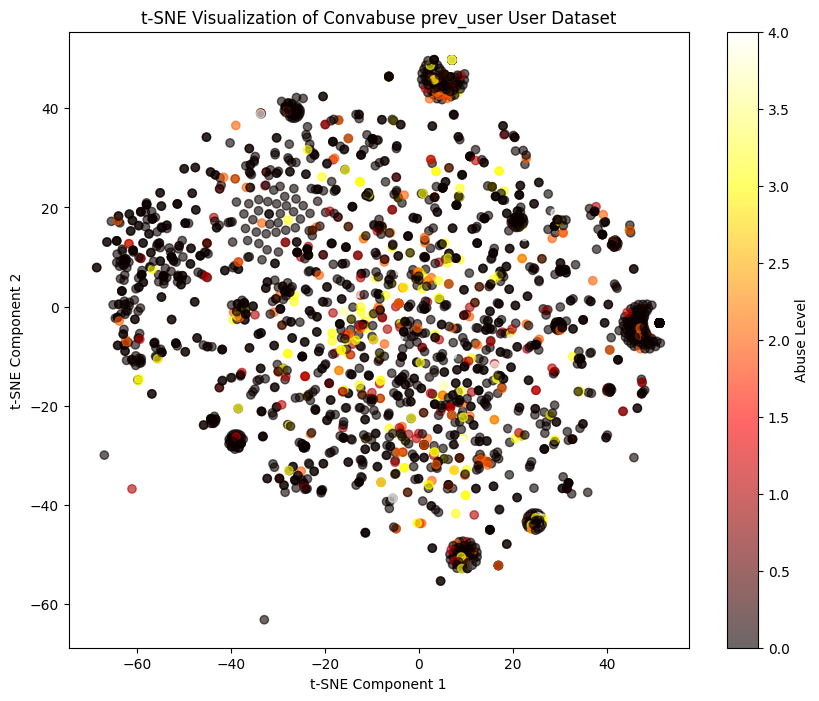

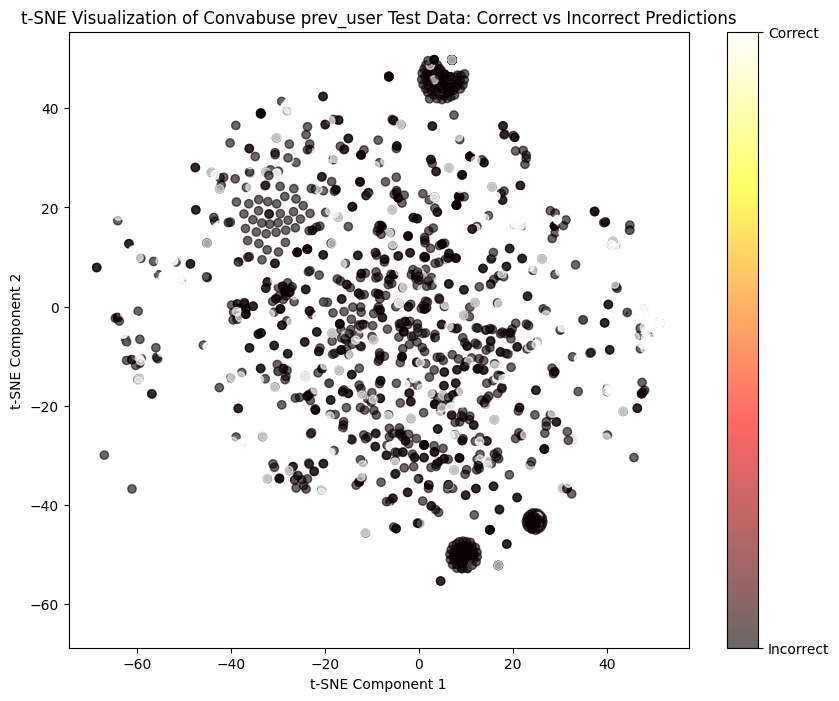

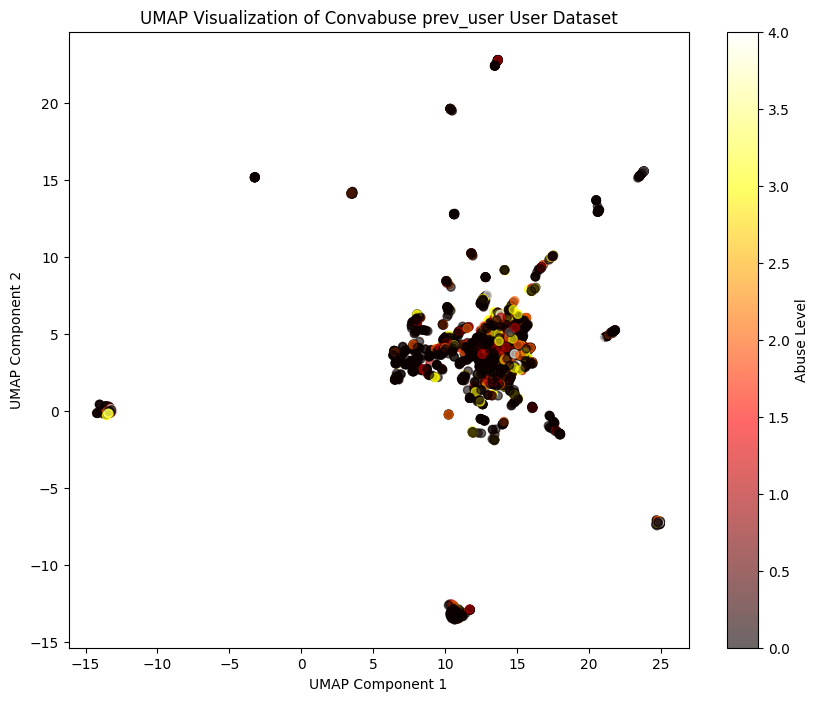

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse prev_user,l1,liblinear,0.465024,0.551954,0.0
1,Convabuse prev_user,l1,saga,0.465819,0.553115,0.0
2,Convabuse prev_user,l2,lbfgs,0.466216,0.553112,0.0
3,Convabuse prev_user,l2,liblinear,0.471383,0.557337,0.0
4,Convabuse prev_user,l2,newton-cg,0.465421,0.552403,0.0
5,Convabuse prev_user,l2,newton-cholesky,0.467409,0.554217,0.0
6,Convabuse prev_user,l2,sag,0.464626,0.551628,0.0
7,Convabuse prev_user,l2,saga,0.467409,0.554217,0.0
8,Convabuse prev_user,elasticnet,saga,0.466216,0.553588,0.5


In [28]:
convabuse_prev_user_results_list = logistic_regression_modeling(convabuse_prev_user_X_train, convabuse_prev_user_X_test, convabuse_prev_user_y_train, convabuse_prev_user_y_test, "Abuse Level", "Convabuse prev_user")
convabuse_prev_user_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.4304451510333863, F1-score: 0.531317746801844
Regularizer: l1, Solver: saga, Accuracy: 0.42408585055643877, F1-score: 0.5275386716760303
Regularizer: l2, Solver: lbfgs, Accuracy: 0.42885532591414943, F1-score: 0.5293949410430234
Regularizer: l2, Solver: liblinear, Accuracy: 0.424483306836248, F1-score: 0.525422028206618
Regularizer: l2, Solver: newton-cg, Accuracy: 0.4336248012718601, F1-score: 0.5340141853138416
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.43402225755166934, F1-score: 0.5343862116438838
Regularizer: l2, Solver: sag, Accuracy: 0.4332273449920509, F1-score: 0.5336254087194395
Regularizer: l2, Solver: saga, Accuracy: 0.4332273449920509, F1-score: 0.5336254087194395
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.43402225755166934, F1-score: 0.5346292040040486


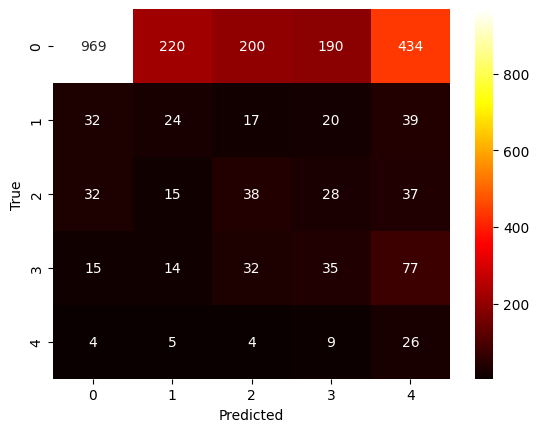

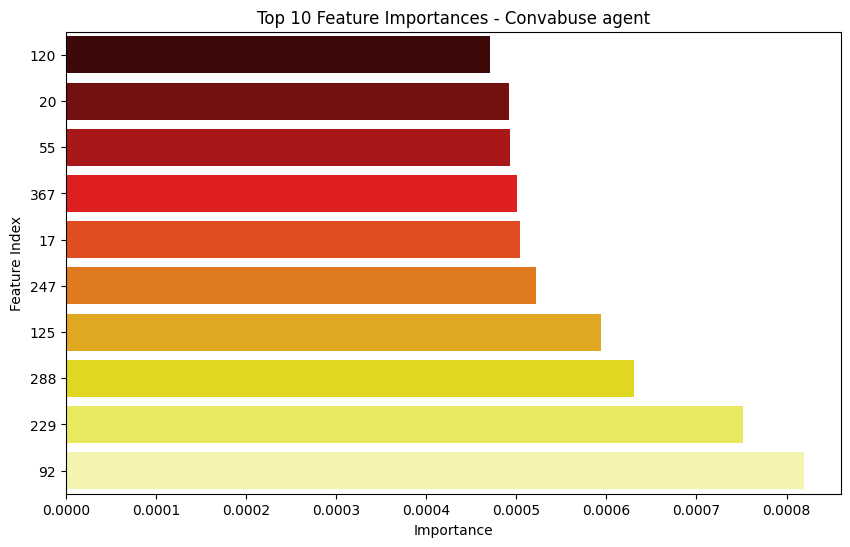

Top 10 Feature Importances
{np.int64(120): np.float32(0.0004708171), np.int64(20): np.float32(0.00049167126), np.int64(55): np.float32(0.0004928112), np.int64(367): np.float32(0.0005008951), np.int64(17): np.float32(0.0005040169), np.int64(247): np.float32(0.00052148104), np.int64(125): np.float32(0.00059398264), np.int64(288): np.float32(0.00063079596), np.int64(229): np.float32(0.00075161457), np.int64(92): np.float32(0.00081920624)}
Linear Coefficients
{0: np.float32(-8.6307526e-05), 1: np.float32(-1.9073486e-06), 2: np.float32(-5.2928925e-05), 3: np.float32(-0.00036385655), 4: np.float32(0.00016272068), 5: np.float32(-3.9190054e-05), 6: np.float32(-0.00049483776), 7: np.float32(3.4570694e-05), 8: np.float32(-3.813207e-05), 9: np.float32(-8.7320805e-05), 10: np.float32(2.6226044e-05), 11: np.float32(0.00011920929), 12: np.float32(-2.9802322e-08), 13: np.float32(-0.00010019541), 14: np.float32(7.236004e-05), 15: np.float32(1.8000603e-05), 16: np.float32(-9.357929e-06), 17: np.float32

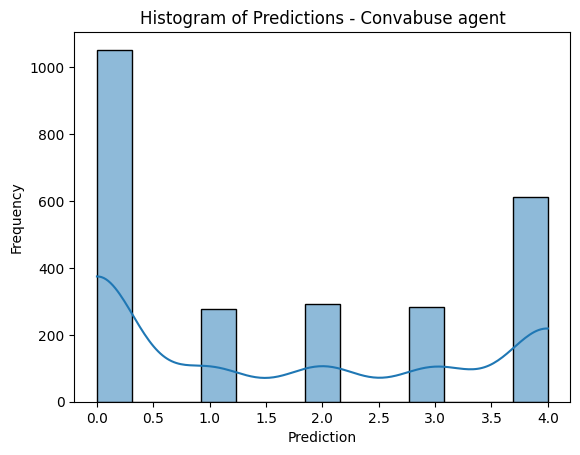

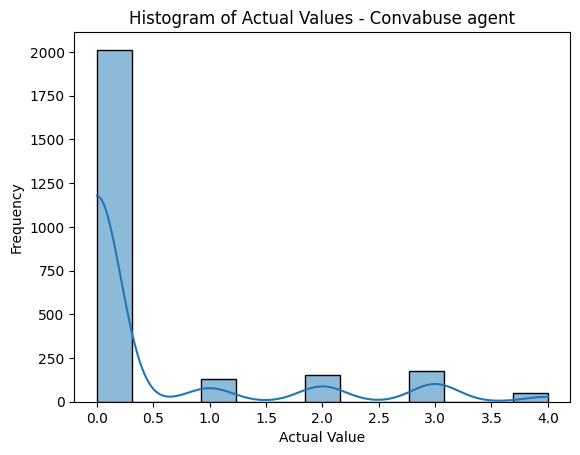

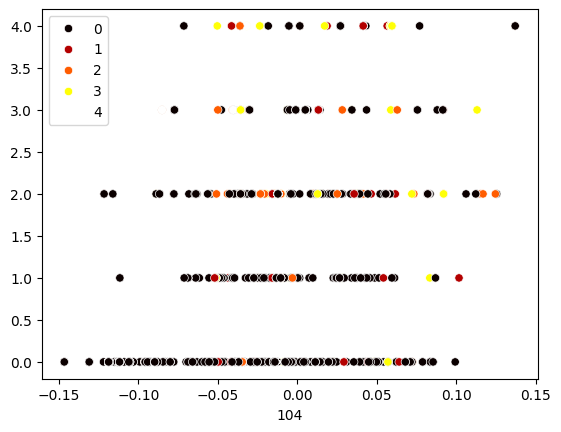

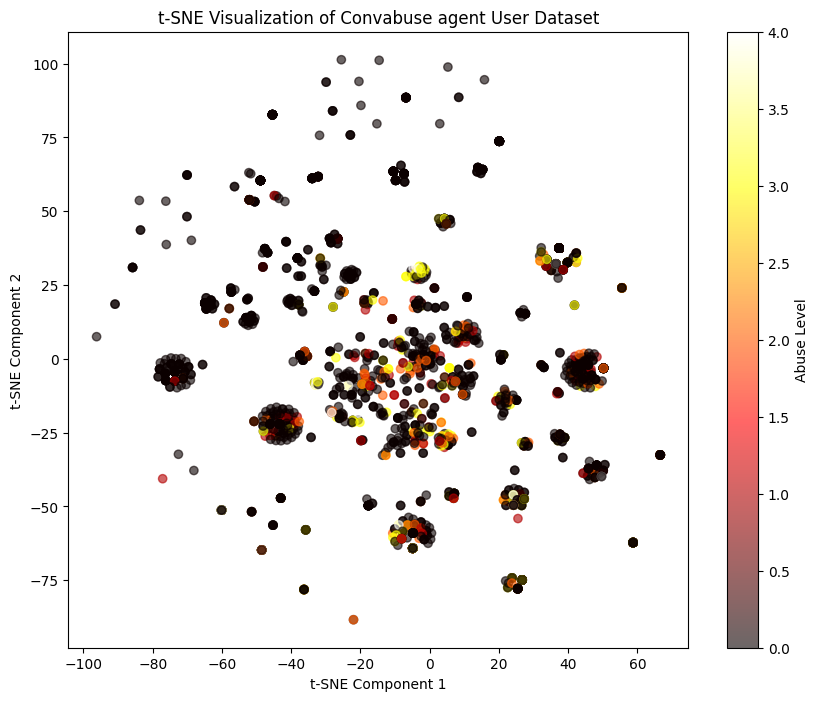

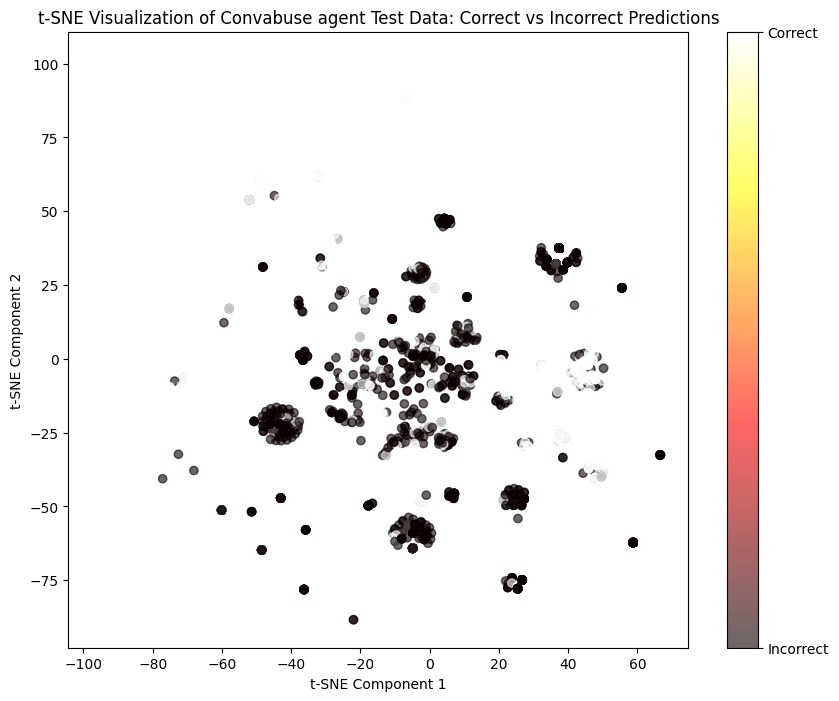

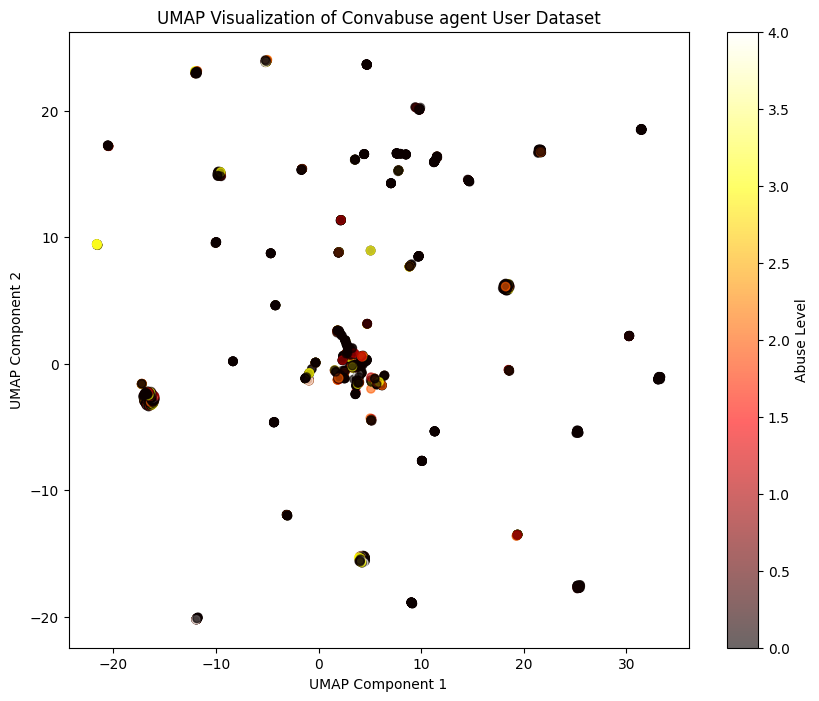

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse agent,l1,liblinear,0.430445,0.531318,0.0
1,Convabuse agent,l1,saga,0.424086,0.527539,0.0
2,Convabuse agent,l2,lbfgs,0.428855,0.529395,0.0
3,Convabuse agent,l2,liblinear,0.424483,0.525422,0.0
4,Convabuse agent,l2,newton-cg,0.433625,0.534014,0.0
5,Convabuse agent,l2,newton-cholesky,0.434022,0.534386,0.0
6,Convabuse agent,l2,sag,0.433227,0.533625,0.0
7,Convabuse agent,l2,saga,0.433227,0.533625,0.0
8,Convabuse agent,elasticnet,saga,0.434022,0.534629,0.5


In [29]:
convabuse_agent_results_list = logistic_regression_modeling(convabuse_agent_X_train, convabuse_agent_X_test, convabuse_agent_y_train, convabuse_agent_y_test, "Abuse Level", "Convabuse agent")
convabuse_agent_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.6883942766295708, F1-score: 0.7372564839602707
Regularizer: l1, Solver: saga, Accuracy: 0.6927662957074722, F1-score: 0.7412191026296213
Regularizer: l2, Solver: lbfgs, Accuracy: 0.7023052464228935, F1-score: 0.749320318514875
Regularizer: l2, Solver: liblinear, Accuracy: 0.6955484896661367, F1-score: 0.7439232795381111
Regularizer: l2, Solver: newton-cg, Accuracy: 0.699523052464229, F1-score: 0.7478531636152785
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.6999205087440381, F1-score: 0.7483314872571702
Regularizer: l2, Solver: sag, Accuracy: 0.6999205087440381, F1-score: 0.7483314872571702
Regularizer: l2, Solver: saga, Accuracy: 0.6999205087440381, F1-score: 0.7483314872571702
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.6971383147853736, F1-score: 0.7459043218719633


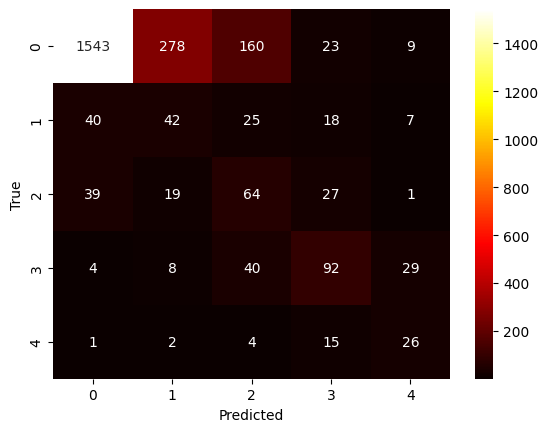

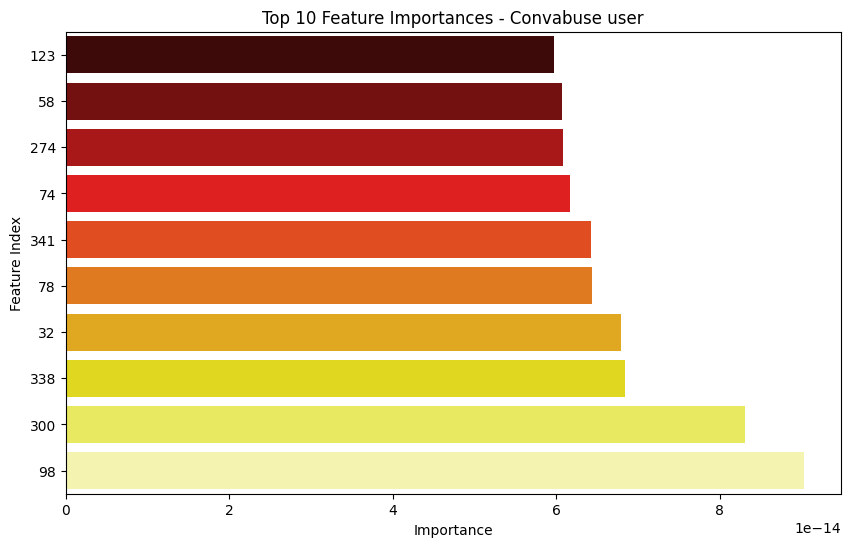

Top 10 Feature Importances
{np.int64(123): np.float64(5.972999872483342e-14), np.int64(58): np.float64(6.072919944699606e-14), np.int64(274): np.float64(6.084022174945858e-14), np.int64(74): np.float64(6.17284001691587e-14), np.int64(341): np.float64(6.419864639894968e-14), np.int64(78): np.float64(6.439293542825908e-14), np.int64(32): np.float64(6.794564910705958e-14), np.int64(338): np.float64(6.838973831690964e-14), np.int64(300): np.float64(8.304468224196171e-14), np.int64(98): np.float64(9.026113190202523e-14)}
Linear Coefficients
{0: np.float64(-1.3322676295501878e-15), 1: np.float64(-1.2656542480726785e-14), 2: np.float64(6.328271240363392e-15), 3: np.float64(4.629630012686903e-14), 4: np.float64(-1.3322676295501878e-15), 5: np.float64(-4.3520742565306136e-14), 6: np.float64(4.574118861455645e-14), 7: np.float64(-2.9531932455029164e-14), 8: np.float64(-1.5987211554602254e-14), 9: np.float64(-3.1530333899354446e-14), 10: np.float64(3.019806626980426e-14), 11: np.float64(-1.931788

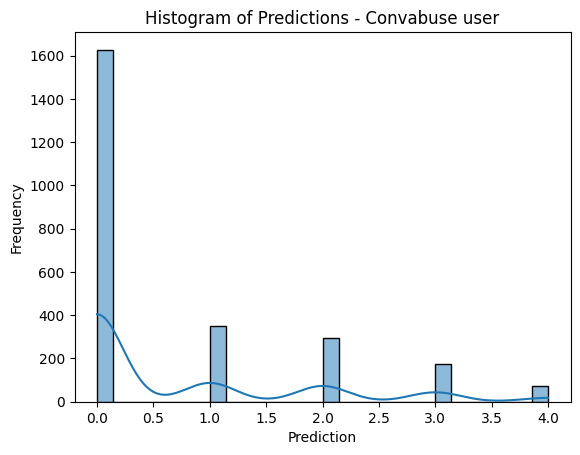

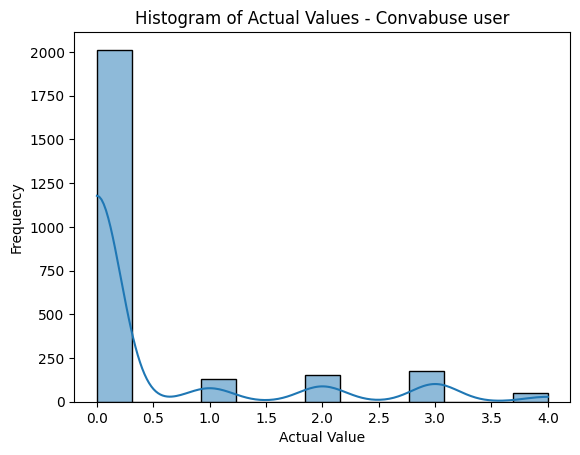

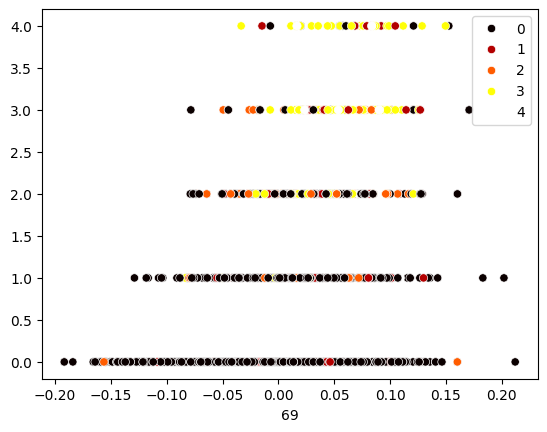

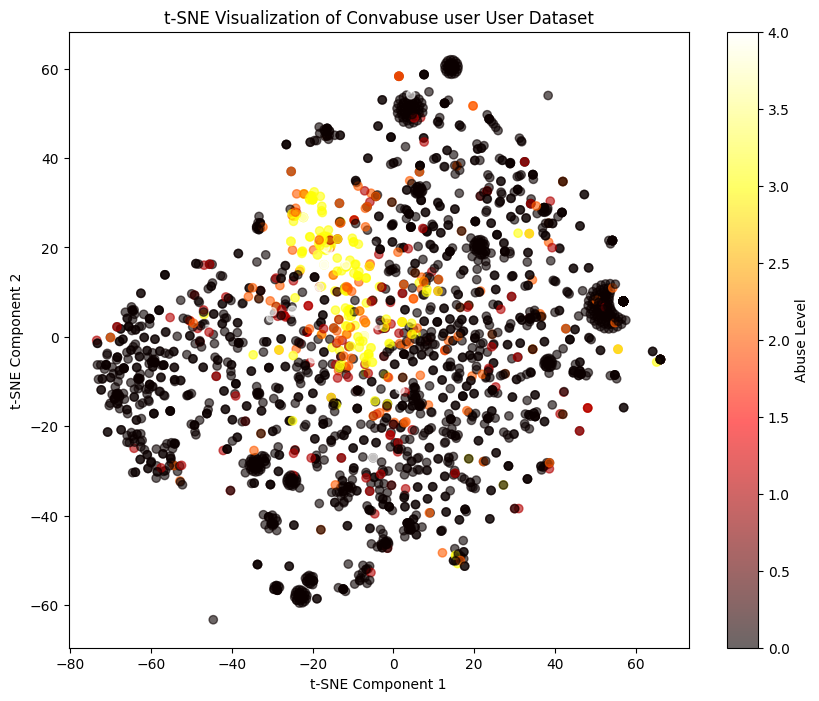

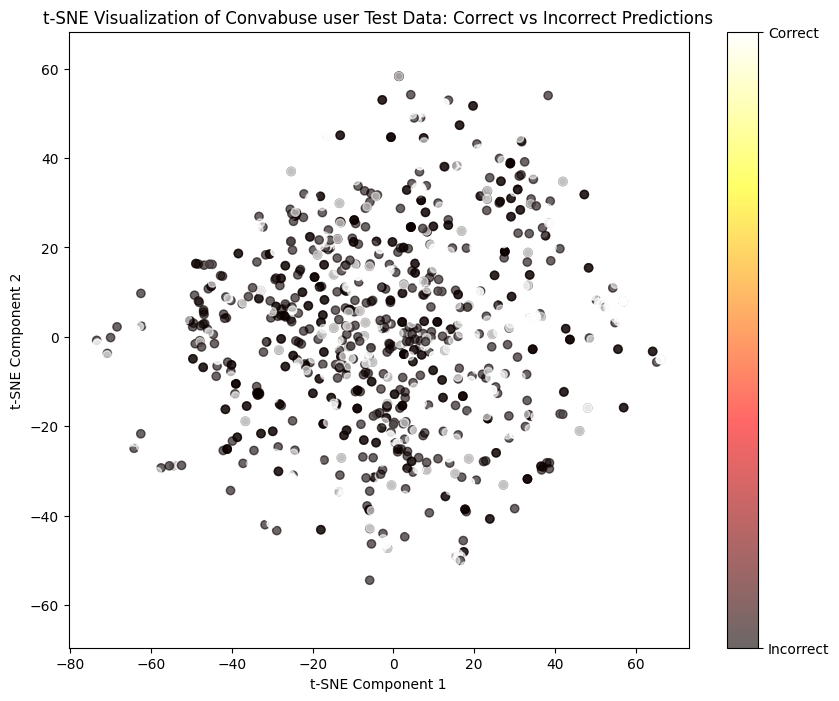

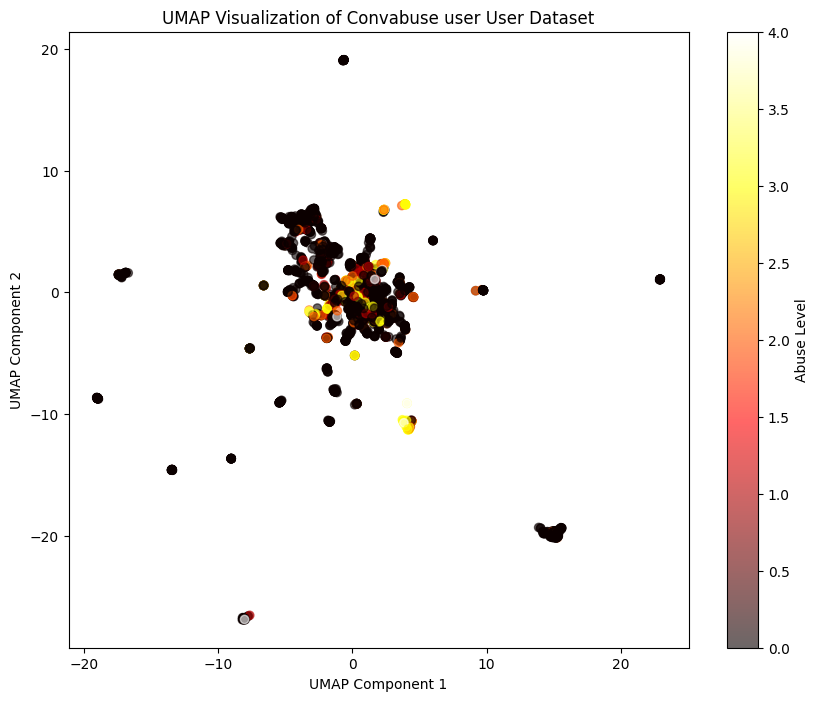

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse user,l1,liblinear,0.688394,0.737256,0.0
1,Convabuse user,l1,saga,0.692766,0.741219,0.0
2,Convabuse user,l2,lbfgs,0.702305,0.749320,0.0
3,Convabuse user,l2,liblinear,0.695548,0.743923,0.0
4,Convabuse user,l2,newton-cg,0.699523,0.747853,0.0
5,Convabuse user,l2,newton-cholesky,0.699921,0.748331,0.0
6,Convabuse user,l2,sag,0.699921,0.748331,0.0
7,Convabuse user,l2,saga,0.699921,0.748331,0.0
8,Convabuse user,elasticnet,saga,0.697138,0.745904,0.5


In [30]:
convabuse_user_results_list = logistic_regression_modeling(convabuse_user_X_train, convabuse_user_X_test, convabuse_user_y_train, convabuse_user_y_test, "Abuse Level", "Convabuse user")
convabuse_user_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.6811187103077675, F1-score: 0.7016217150774605
Regularizer: l1, Solver: saga, Accuracy: 0.6812408402540303, F1-score: 0.7017294777680398
Regularizer: l2, Solver: lbfgs, Accuracy: 0.6783097215437225, F1-score: 0.69916650176067
Regularizer: l2, Solver: liblinear, Accuracy: 0.6805080605764533, F1-score: 0.7011848108197405
Regularizer: l2, Solver: newton-cg, Accuracy: 0.680019540791402, F1-score: 0.7007152964162316
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.6803859306301905, F1-score: 0.7010768657628856
Regularizer: l2, Solver: sag, Accuracy: 0.6803859306301905, F1-score: 0.7010768657628856
Regularizer: l2, Solver: saga, Accuracy: 0.6805080605764533, F1-score: 0.7011848108197405
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.6802638006839277, F1-score: 0.7009563588402449


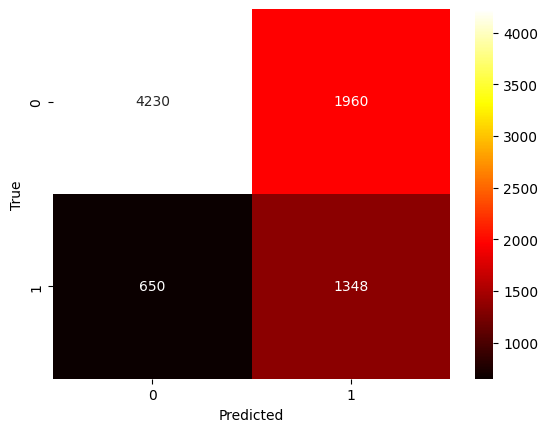

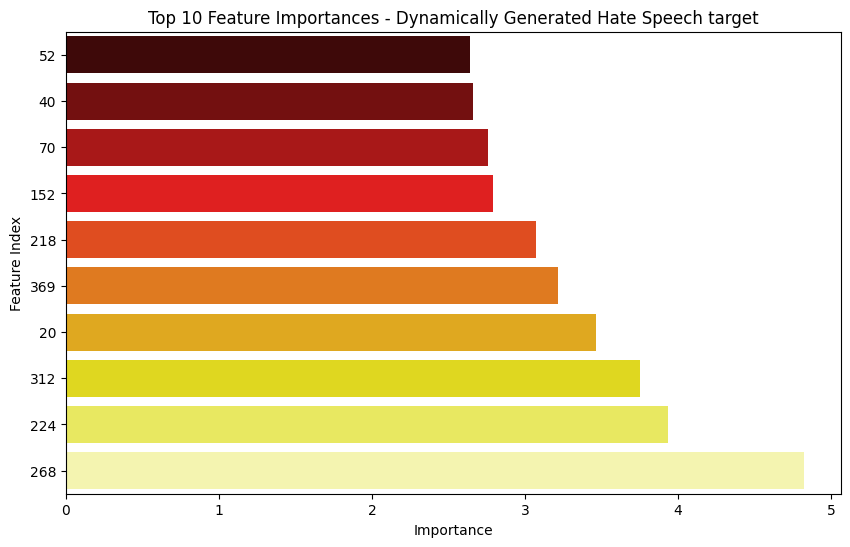

Top 10 Feature Importances
{np.int64(52): np.float32(2.640829), np.int64(40): np.float32(2.6616163), np.int64(70): np.float32(2.760909), np.int64(152): np.float32(2.7925406), np.int64(218): np.float32(3.0737495), np.int64(369): np.float32(3.2157664), np.int64(20): np.float32(3.4655023), np.int64(312): np.float32(3.7524781), np.int64(224): np.float32(3.9354358), np.int64(268): np.float32(4.8223023)}
Linear Coefficients
{0: np.float32(-0.40916964), 1: np.float32(-1.7373565), 2: np.float32(-1.3370728), 3: np.float32(-2.3178263), 4: np.float32(0.9020398), 5: np.float32(-0.37272653), 6: np.float32(0.0), 7: np.float32(-1.1803318), 8: np.float32(0.3029734), 9: np.float32(1.94399), 10: np.float32(-2.45547), 11: np.float32(0.782954), 12: np.float32(-0.51173717), 13: np.float32(0.06640581), 14: np.float32(-3.142127), 15: np.float32(-0.50756913), 16: np.float32(-0.7197999), 17: np.float32(-1.2009459), 18: np.float32(-1.5144597), 19: np.float32(0.0), 20: np.float32(3.4655023), 21: np.float32(1.463

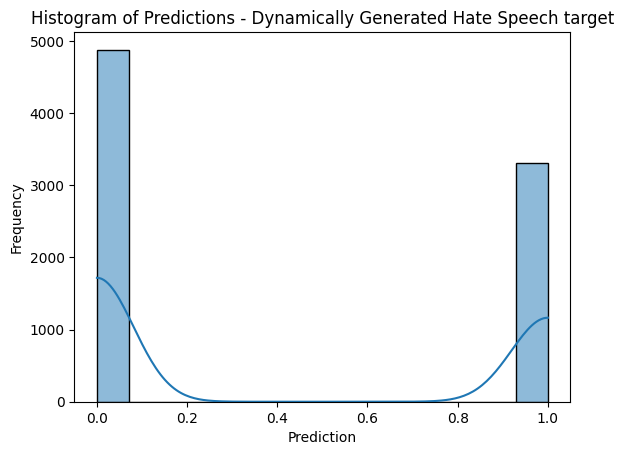

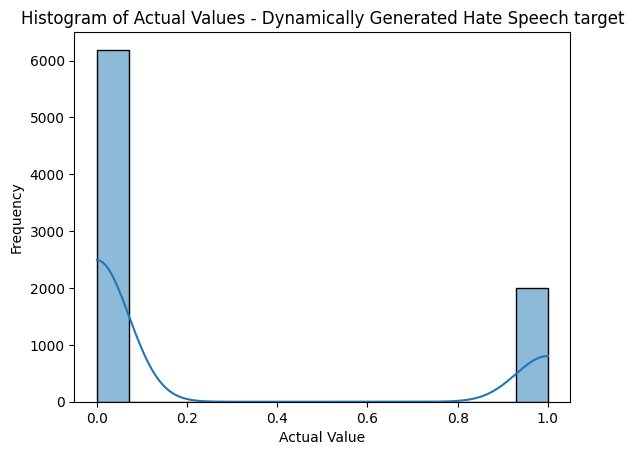

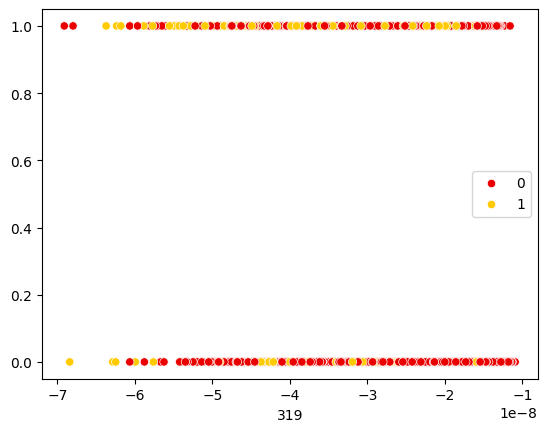

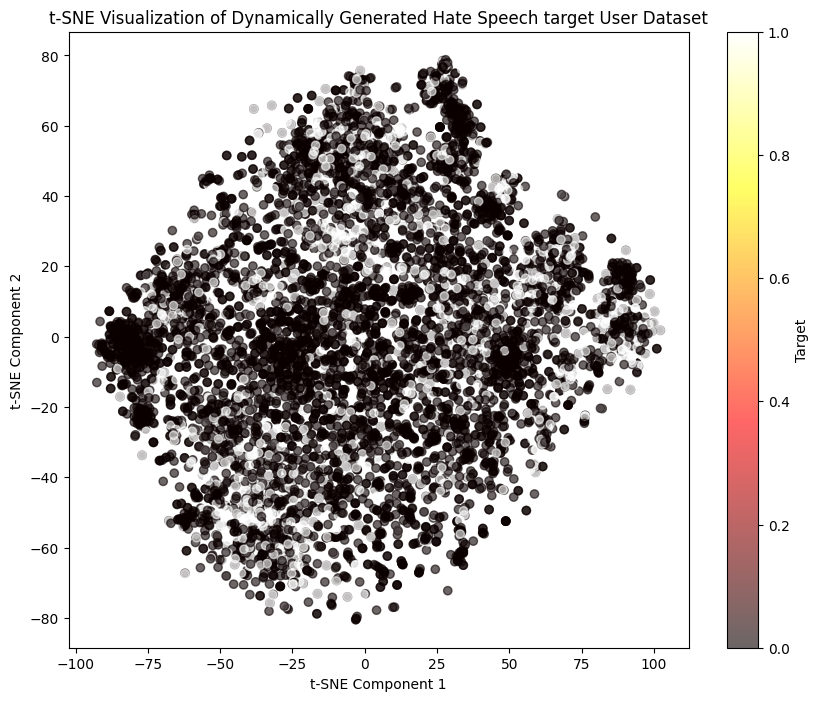

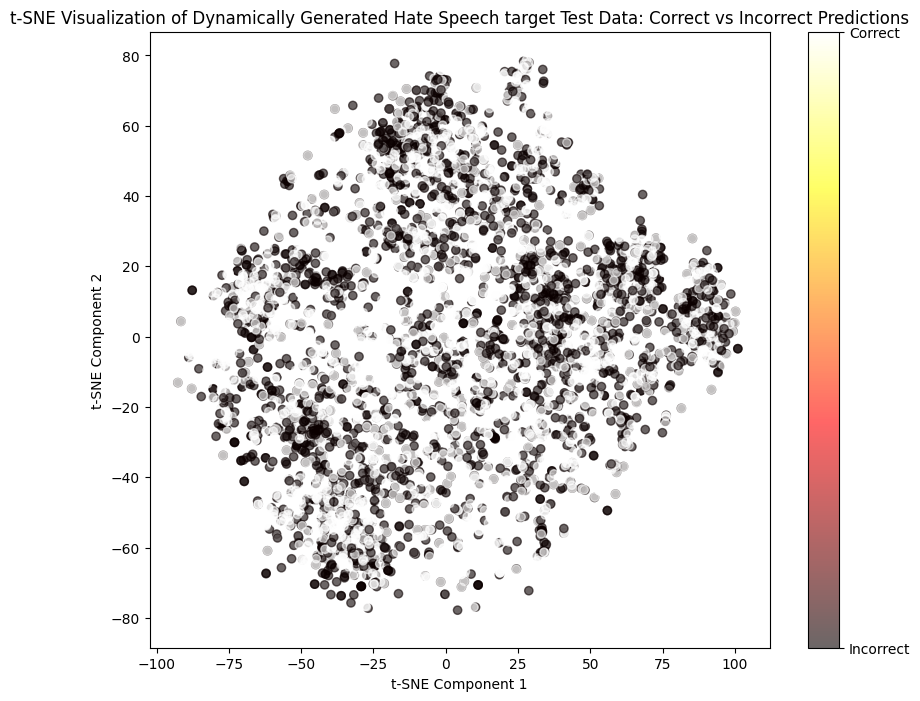

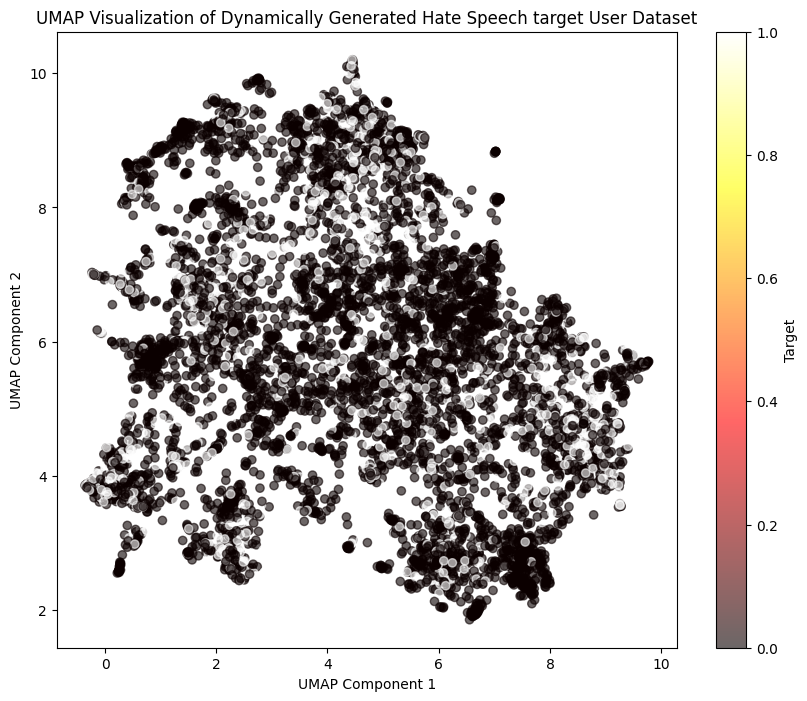

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Dynamically Generated Hate Speech target,l1,liblinear,0.681119,0.701622,0.0
1,Dynamically Generated Hate Speech target,l1,saga,0.681241,0.701729,0.0
2,Dynamically Generated Hate Speech target,l2,lbfgs,0.678310,0.699167,0.0
3,Dynamically Generated Hate Speech target,l2,liblinear,0.680508,0.701185,0.0
4,Dynamically Generated Hate Speech target,l2,newton-cg,0.680020,0.700715,0.0
5,Dynamically Generated Hate Speech target,l2,newton-cholesky,0.680386,0.701077,0.0
6,Dynamically Generated Hate Speech target,l2,sag,0.680386,0.701077,0.0
7,Dynamically Generated Hate Speech target,l2,saga,0.680508,0.701185,0.0
8,Dynamically Generated Hate Speech target,elasticnet,saga,0.680264,0.700956,0.5


In [31]:
dghs_target_results_list = logistic_regression_modeling(dynamically_generated_hate_speech_target_X_train, dynamically_generated_hate_speech_target_X_test, dynamically_generated_hate_speech_target_y_train, dynamically_generated_hate_speech_target_y_test, "Target", "Dynamically Generated Hate Speech target")
dghs_target_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.7040791402051783, F1-score: 0.7042120348412458
Regularizer: l1, Solver: saga, Accuracy: 0.7040791402051783, F1-score: 0.7042120348412458
Regularizer: l2, Solver: lbfgs, Accuracy: 0.7042012701514412, F1-score: 0.7043405778275571
Regularizer: l2, Solver: liblinear, Accuracy: 0.7039570102589154, F1-score: 0.7041174296696803
Regularizer: l2, Solver: newton-cg, Accuracy: 0.7037127503663898, F1-score: 0.7038650038043319
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.7039570102589154, F1-score: 0.7041215218355048
Regularizer: l2, Solver: sag, Accuracy: 0.7038348803126526, F1-score: 0.7040014932857667
Regularizer: l2, Solver: saga, Accuracy: 0.7038348803126526, F1-score: 0.7040014932857667
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.7037127503663898, F1-score: 0.7038479780110775


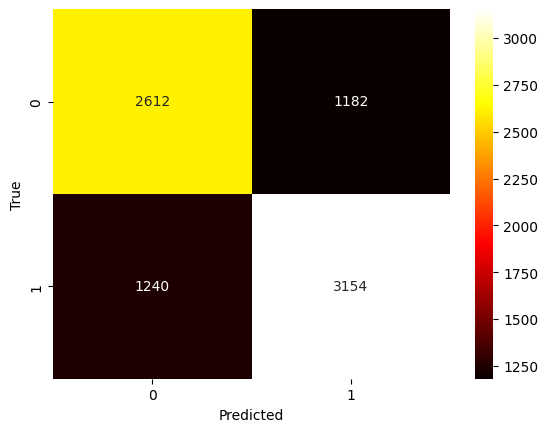

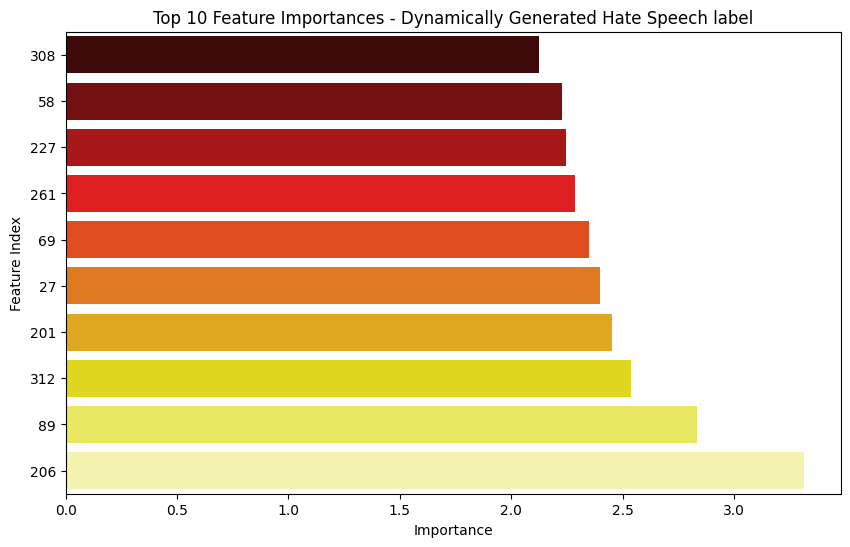

Top 10 Feature Importances
{np.int64(308): np.float64(2.1264015396022047), np.int64(58): np.float64(2.2265124589186644), np.int64(227): np.float64(2.2473683634945094), np.int64(261): np.float64(2.287320528411718), np.int64(69): np.float64(2.347617079702068), np.int64(27): np.float64(2.3981441395101), np.int64(201): np.float64(2.452951360737383), np.int64(312): np.float64(2.5373054409532), np.int64(89): np.float64(2.8347395108442366), np.int64(206): np.float64(3.314404349768329)}
Linear Coefficients
{0: np.float64(-1.1516927104059806), 1: np.float64(0.8310048204162819), 2: np.float64(-1.559335658365521), 3: np.float64(-0.9164377239607319), 4: np.float64(0.13279176696487358), 5: np.float64(0.025598871100132817), 6: np.float64(1.8814562940666242), 7: np.float64(-2.584228308939715), 8: np.float64(1.102013124416144), 9: np.float64(0.2841312402876171), 10: np.float64(0.33149430687595377), 11: np.float64(-0.09178504418978295), 12: np.float64(-0.6962251855862681), 13: np.float64(0.216149627244

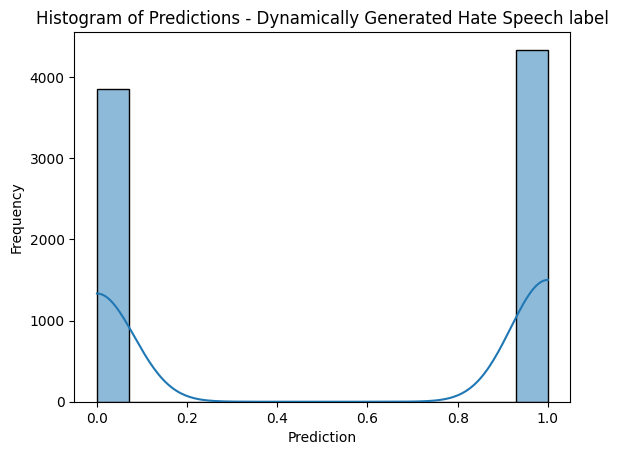

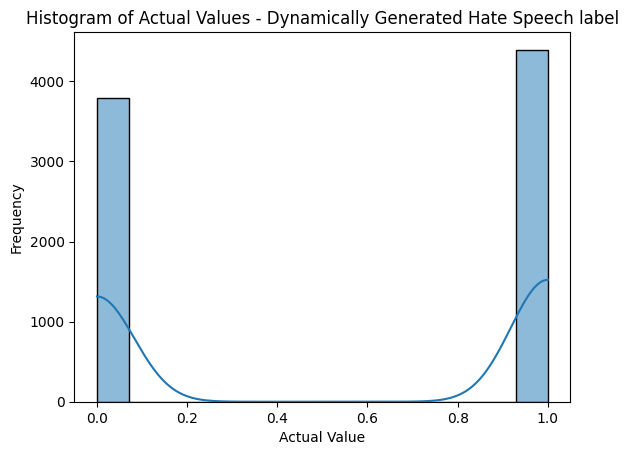

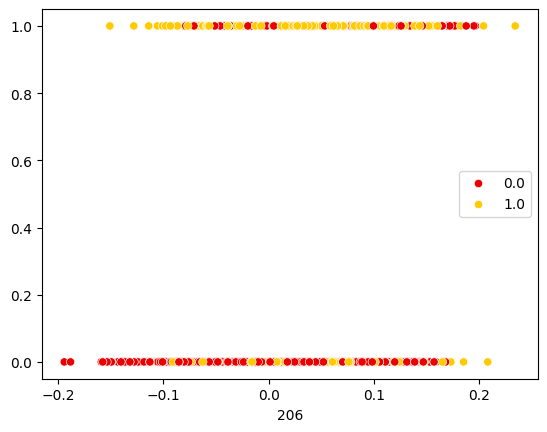

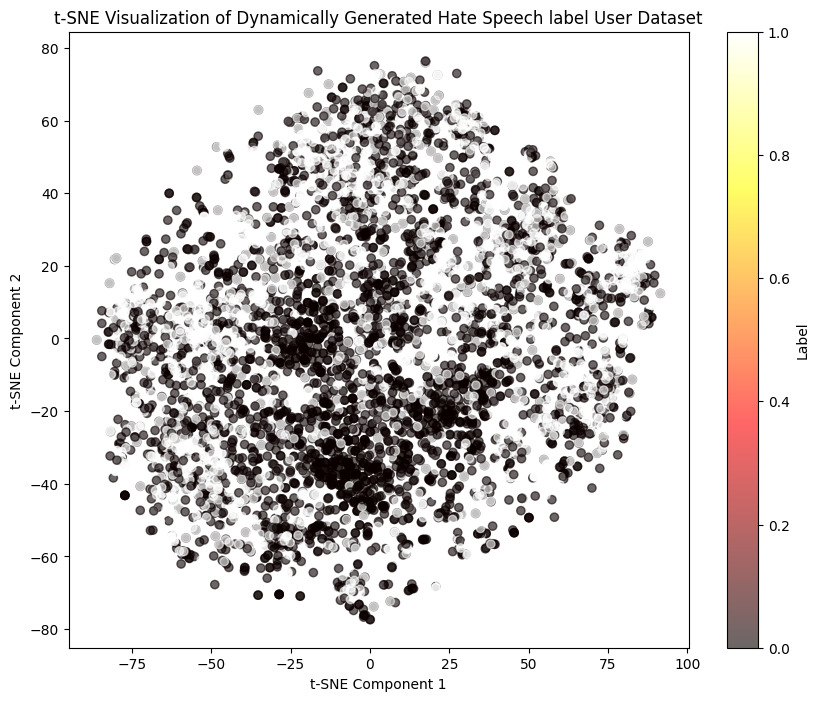

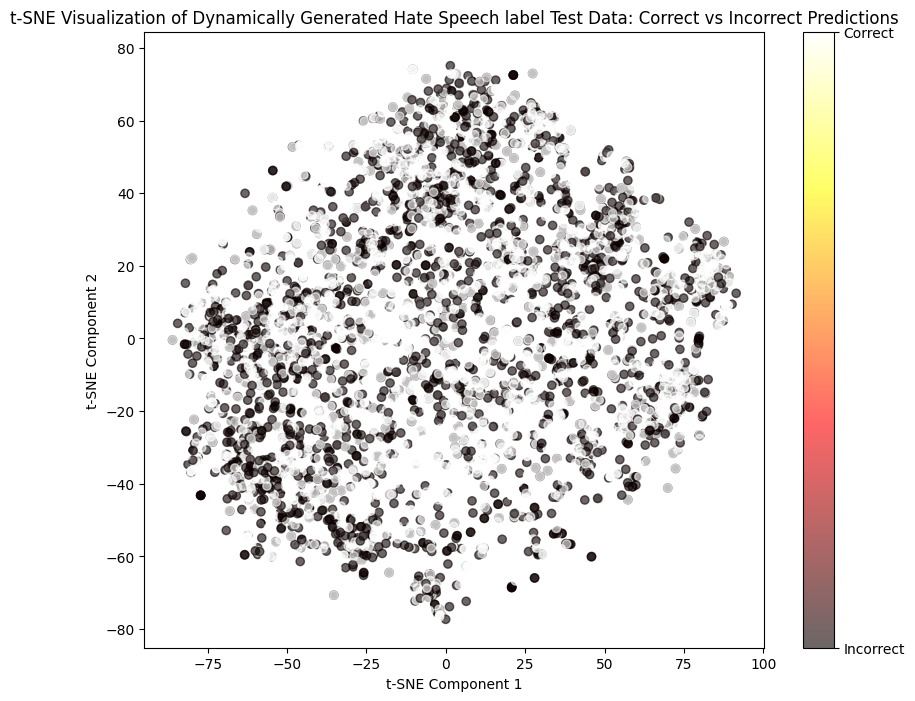

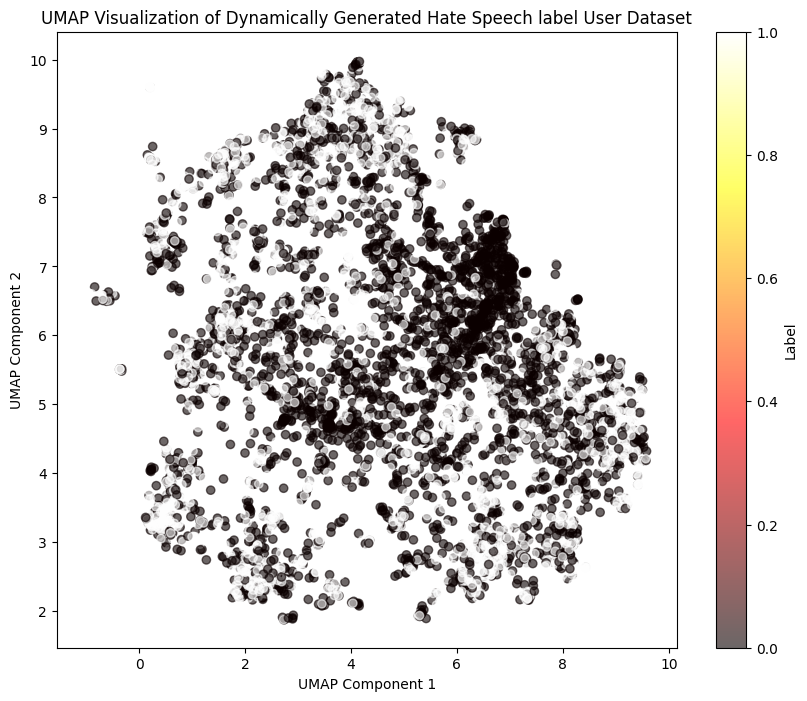

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Dynamically Generated Hate Speech label,l1,liblinear,0.704079,0.704212,0.0
1,Dynamically Generated Hate Speech label,l1,saga,0.704079,0.704212,0.0
2,Dynamically Generated Hate Speech label,l2,lbfgs,0.704201,0.704341,0.0
3,Dynamically Generated Hate Speech label,l2,liblinear,0.703957,0.704117,0.0
4,Dynamically Generated Hate Speech label,l2,newton-cg,0.703713,0.703865,0.0
5,Dynamically Generated Hate Speech label,l2,newton-cholesky,0.703957,0.704122,0.0
6,Dynamically Generated Hate Speech label,l2,sag,0.703835,0.704001,0.0
7,Dynamically Generated Hate Speech label,l2,saga,0.703835,0.704001,0.0
8,Dynamically Generated Hate Speech label,elasticnet,saga,0.703713,0.703848,0.5


In [32]:
dghs_label_results_list = logistic_regression_modeling(dynamically_generated_hate_speech_label_X_train, dynamically_generated_hate_speech_label_X_test, dynamically_generated_hate_speech_label_y_train, dynamically_generated_hate_speech_label_y_test, "Label", "Dynamically Generated Hate Speech label")
dghs_label_results_list

Regularizer: l1, Solver: liblinear, Accuracy: 0.4555112881806109, F1-score: 0.49271179704492857
Regularizer: l1, Solver: saga, Accuracy: 0.45506861443116425, F1-score: 0.4904730294352524
Regularizer: l2, Solver: lbfgs, Accuracy: 0.45506861443116425, F1-score: 0.49406598337436974
Regularizer: l2, Solver: liblinear, Accuracy: 0.44754316069057104, F1-score: 0.48965267471592033
Regularizer: l2, Solver: newton-cg, Accuracy: 0.4541832669322709, F1-score: 0.4928730317143984
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.4555112881806109, F1-score: 0.49405525804100875
Regularizer: l2, Solver: sag, Accuracy: 0.45506861443116425, F1-score: 0.49358262688264315
Regularizer: l2, Solver: saga, Accuracy: 0.4555112881806109, F1-score: 0.4941495013909379
Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.45506861443116425, F1-score: 0.4926376134177832


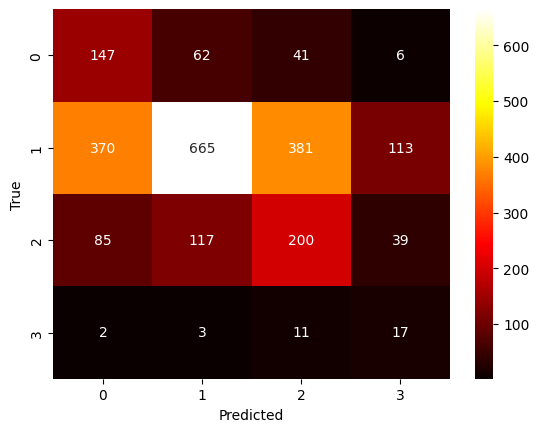

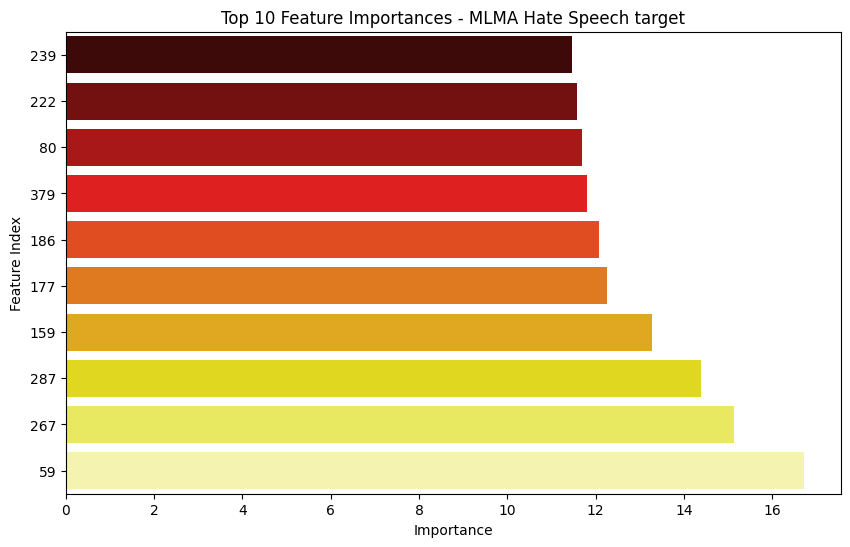

Top 10 Feature Importances
{np.int64(239): np.float64(11.461678522276829), np.int64(222): np.float64(11.57945740666803), np.int64(80): np.float64(11.699694383080354), np.int64(379): np.float64(11.807174343956644), np.int64(186): np.float64(12.08007227535767), np.int64(177): np.float64(12.255289965751992), np.int64(159): np.float64(13.270398596045293), np.int64(287): np.float64(14.395396220105994), np.int64(267): np.float64(15.127255622164816), np.int64(59): np.float64(16.72194673314593)}
Linear Coefficients
{0: np.float64(-3.073697410596294), 1: np.float64(3.043959125353113), 2: np.float64(0.5678575418656959), 3: np.float64(-1.3403427476818788), 4: np.float64(-0.9270247751290047), 5: np.float64(-4.425345137641168), 6: np.float64(10.302873828005541), 7: np.float64(-2.705445530246209), 8: np.float64(9.374421805294714), 9: np.float64(-9.310899339063804), 10: np.float64(0.7596418413738533), 11: np.float64(0.45204862170186666), 12: np.float64(-2.9017740170932735), 13: np.float64(-4.65015514

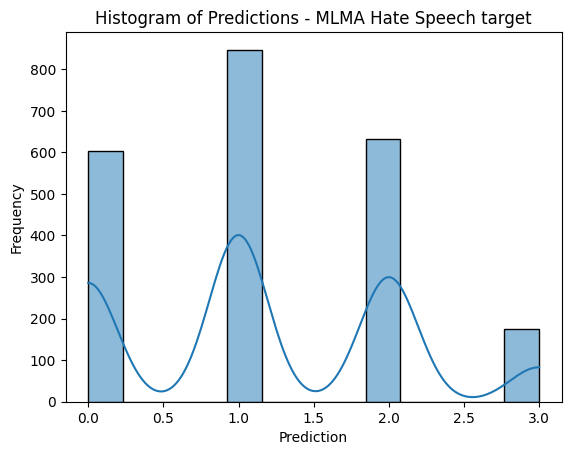

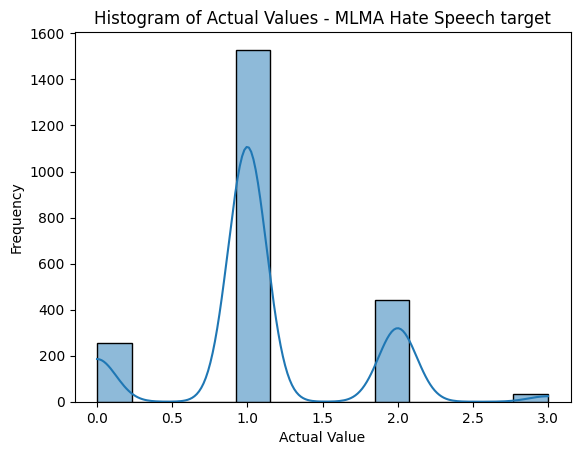

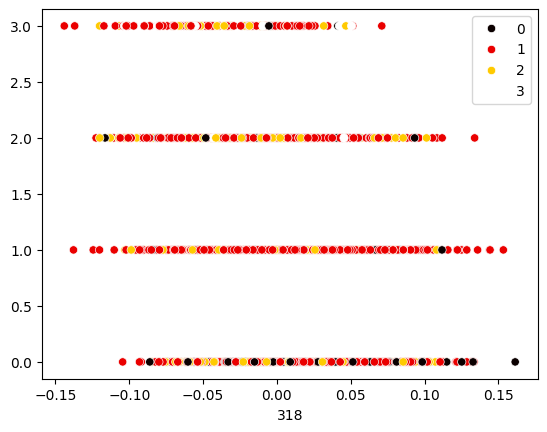

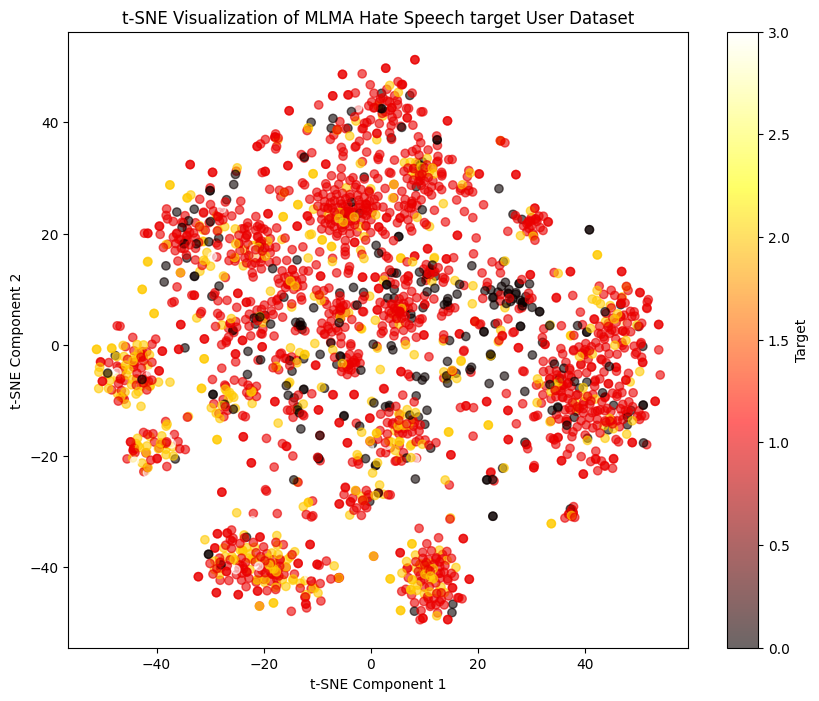

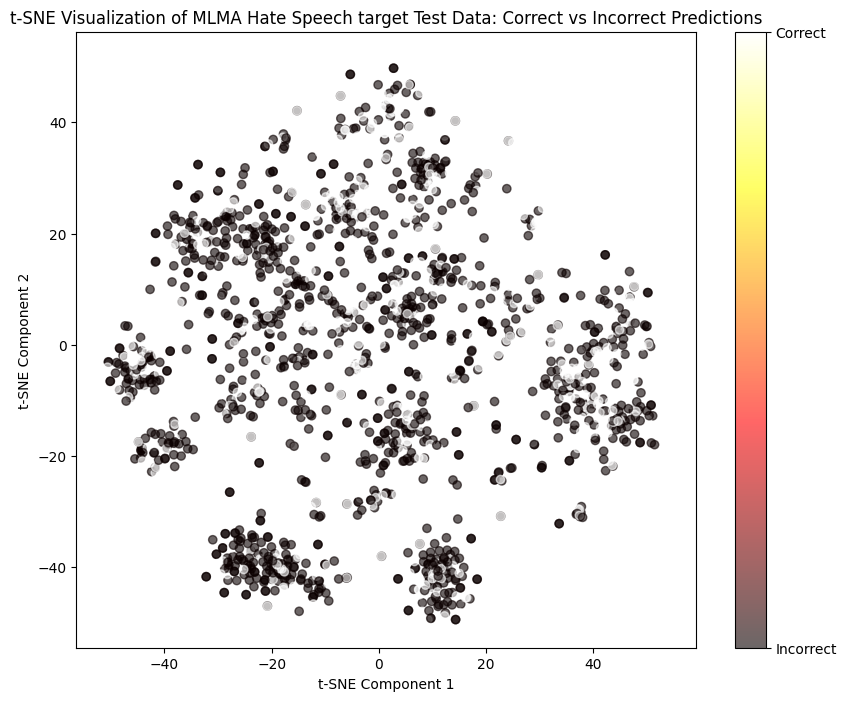

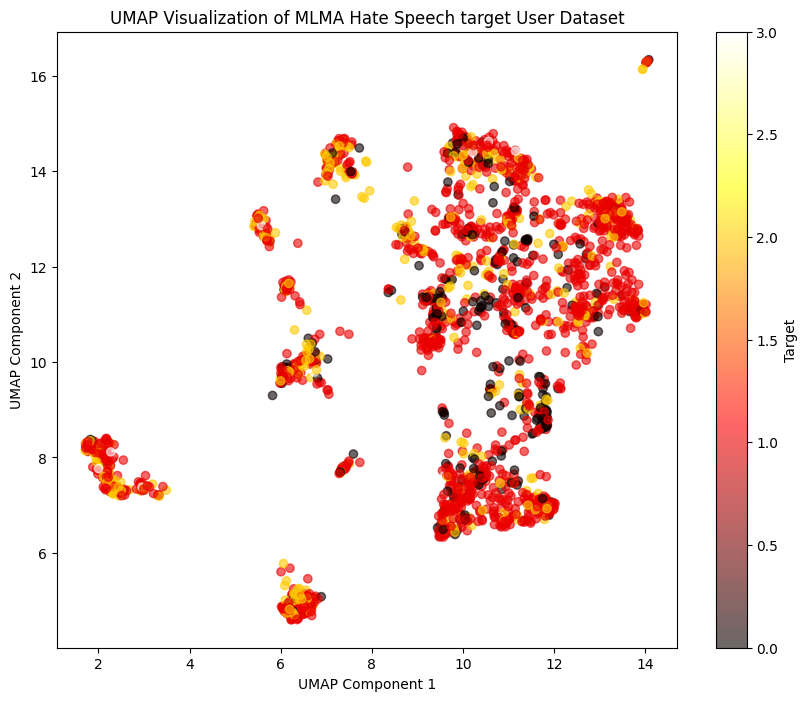

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,MLMA Hate Speech target,l1,liblinear,0.455511,0.492712,0.0
1,MLMA Hate Speech target,l1,saga,0.455069,0.490473,0.0
2,MLMA Hate Speech target,l2,lbfgs,0.455069,0.494066,0.0
3,MLMA Hate Speech target,l2,liblinear,0.447543,0.489653,0.0
4,MLMA Hate Speech target,l2,newton-cg,0.454183,0.492873,0.0
5,MLMA Hate Speech target,l2,newton-cholesky,0.455511,0.494055,0.0
6,MLMA Hate Speech target,l2,sag,0.455069,0.493583,0.0
7,MLMA Hate Speech target,l2,saga,0.455511,0.494150,0.0
8,MLMA Hate Speech target,elasticnet,saga,0.455069,0.492638,0.5


In [33]:
mlma_hate_speech_results_list = logistic_regression_modeling(mlma_hate_speech_target_X_train, mlma_hate_speech_target_X_test, mlma_hate_speech_target_y_train, mlma_hate_speech_target_y_test, "Target", "MLMA Hate Speech target")
mlma_hate_speech_results_list

## Logistic Regression Conclusions

In [34]:
logistic_regression_model_results

[('Convabuse combined',
  Dataset        Convabuse combined
  Regularizer                    l2
  Solver                  liblinear
  Accuracy                 0.643879
  F1-score                 0.705204
  Ratio                         0.0
  Name: 3, dtype: object,
  0.643879173290938,
  0.7052040374691624,
  0.0,
  {0: np.float64(-1.1665910251555753),
   1: np.float64(3.5262021446676504),
   2: np.float64(1.3331076944467006),
   3: np.float64(-1.7284678389722576),
   4: np.float64(0.6738177302654534),
   5: np.float64(0.46911763961467723),
   6: np.float64(2.4967575463955867),
   7: np.float64(-1.2646194694069248),
   8: np.float64(2.113153218995343),
   9: np.float64(-2.6514455942281843),
   10: np.float64(0.2858632226875576),
   11: np.float64(0.9234575536315102),
   12: np.float64(3.702961068102992),
   13: np.float64(3.48670051233141),
   14: np.float64(-0.018694615478661913),
   15: np.float64(-3.722572790812557),
   16: np.float64(0.18864089112719062),
   17: np.float64(-2.07669

In [35]:
# Remove the first entry from logistic_regression_model_results
logistic_regression_model_results = logistic_regression_model_results[1:]
logistic_regression_model_results

[('Convabuse prev_agent',
  Dataset        Convabuse prev_agent
  Regularizer                      l1
  Solver                         saga
  Accuracy                    0.40461
  F1-score                   0.501601
  Ratio                           0.0
  Name: 1, dtype: object,
  0.404610492845787,
  0.5016006025674037,
  0.0,
  {0: np.float32(-0.8718583),
   1: np.float32(6.904414),
   2: np.float32(0.0),
   3: np.float32(-1.2612977),
   4: np.float32(0.9808035),
   5: np.float32(0.99919415),
   6: np.float32(0.030414581),
   7: np.float32(2.9605258),
   8: np.float32(4.194113),
   9: np.float32(-1.9282374),
   10: np.float32(0.0),
   11: np.float32(16.017132),
   12: np.float32(12.820061),
   13: np.float32(-0.9769467),
   14: np.float32(-4.6302137),
   15: np.float32(0.0),
   16: np.float32(-2.0656831),
   17: np.float32(2.7865314),
   18: np.float32(-6.3641243),
   19: np.float32(-2.2884822),
   20: np.float32(-1.0452511),
   21: np.float32(3.000755),
   22: np.float32(-5.0396643)

In [36]:
logistic_regression_TSNE

{'Convabuse combined': array([[ 37.914837 ,  17.26702  ],
        [-27.81499  ,   5.9093776],
        [-36.848076 , -23.49684  ],
        ...,
        [-44.504234 ,  20.00941  ],
        [-34.233578 ,  41.310444 ],
        [-72.03332  ,  19.049326 ]], dtype=float32),
 'Convabuse prev_agent': array([[ 17.46993  , -30.102415 ],
        [ -4.181342 ,  46.898895 ],
        [ -8.947633 ,  32.214256 ],
        ...,
        [  1.9275497, -26.623495 ],
        [-54.518917 , -19.497519 ],
        [-60.17009  ,  26.078945 ]], dtype=float32),
 'Convabuse prev_user': array([[  9.688327  ,  22.1825    ],
        [-28.162455  ,  20.33583   ],
        [-26.33739   ,  38.48978   ],
        ...,
        [ -0.97529817, -14.486551  ],
        [ 20.58212   ,   0.20495829],
        [ 51.22458   ,  -3.3011668 ]], dtype=float32),
 'Convabuse agent': array([[ 47.078266,  -8.443439],
        [-60.087547, -51.22759 ],
        [ 13.926538,  64.799965],
        ...,
        [-38.1664  ,  34.13463 ],
        [-25.

In [37]:
logistic_regression_UMAP

{'Convabuse combined': array([[ 1.2990575 ,  0.9602602 ],
        [-0.4258993 ,  7.2228527 ],
        [-1.2730256 , 13.179063  ],
        ...,
        [12.398776  ,  3.9552603 ],
        [11.3621235 ,  2.7723966 ],
        [19.23351   , -0.61813927]], dtype=float32),
 'Convabuse prev_agent': array([[-19.9967   ,   5.1298485],
        [ -3.0785491, -15.59181  ],
        [-10.157525 ,   2.0517206],
        ...,
        [  4.977028 ,  -4.497476 ],
        [ 30.964264 ,  14.893356 ],
        [  3.3825781,  20.932137 ]], dtype=float32),
 'Convabuse prev_user': array([[ 12.605826  ,   0.44966424],
        [ 13.513441  ,   4.222508  ],
        [ 23.735256  ,  15.514917  ],
        ...,
        [ 12.926139  ,   3.003311  ],
        [ 15.578077  ,   3.2724724 ],
        [ 10.557074  , -13.485095  ]], dtype=float32),
 'Convabuse agent': array([[ 18.323637 ,   6.188771 ],
        [ -9.671897 ,  15.046391 ],
        [ 10.067943 ,  -7.6878915],
        ...,
        [  7.623655 ,  16.609398 ],
     

In [38]:
# Pickle both dictionaries
with open(f'{pickle_path}logistic-regression-TSNE-dict_sentiment-analysis-SMOTE.pkl', 'wb') as f:
    pickle.dump(logistic_regression_TSNE, f)
with open(f'{pickle_path}logistic-regression-UMAP-dict_sentiment-analysis-SMOTE.pkl', 'wb') as f:
    pickle.dump(logistic_regression_UMAP, f)

In [39]:
logistic_regression_model_summary = pd.DataFrame(logistic_regression_model_results, columns=["Dataset", "Best Parameters", "Accuracy", "F1-score", "Ratio", "Importances", "Feature Importances"])
logistic_regression_model_summary["Balance"] = "SMOTE"
logistic_regression_model_summary["Model"] = "Logistic Regression"
logistic_regression_model_summary

,Dataset,Best Parameters,Accuracy,F1-score,Ratio,Importances,Feature Importances,Balance,Model
0,Convabuse prev_agent,Dataset Convabuse prev_agent Regularize...,0.404610,0.501601,0.0,"{0: -0.8718583, 1: 6.904414, 2: 0.0, 3: -1.261...","{131: 11.366352, 378: 12.40703, 12: 12.820061,...",SMOTE,Logistic Regression
1,Convabuse prev_user,Dataset Convabuse prev_user Regularizer...,0.471383,0.557337,0.0,"{0: -2.6109102025411186, 1: 0.6081769389837652...","{241: 2.532430360362501, 48: 2.562038247276439...",SMOTE,Logistic Regression
2,Convabuse agent,Dataset Convabuse agent Regularizer ...,0.434022,0.534386,0.0,"{0: -8.6307526e-05, 1: -1.9073486e-06, 2: -5.2...","{120: 0.0004708171, 20: 0.00049167126, 55: 0.0...",SMOTE,Logistic Regression
3,Convabuse user,Dataset Convabuse user Regularizer ...,0.702305,0.749320,0.0,"{0: -1.3322676295501878e-15, 1: -1.26565424807...","{123: 5.972999872483342e-14, 58: 6.07291994469...",SMOTE,Logistic Regression
4,Dynamically Generated Hate Speech target,Dataset Dynamically Generated Hate Spee...,0.681241,0.701729,0.0,"{0: -0.40916964, 1: -1.7373565, 2: -1.3370728,...","{52: 2.640829, 40: 2.6616163, 70: 2.760909, 15...",SMOTE,Logistic Regression
5,Dynamically Generated Hate Speech label,Dataset Dynamically Generated Hate Spee...,0.704201,0.704341,0.0,"{0: -1.1516927104059806, 1: 0.8310048204162819...","{308: 2.1264015396022047, 58: 2.22651245891866...",SMOTE,Logistic Regression
6,MLMA Hate Speech target,Dataset MLMA Hate Speech target Regular...,0.455511,0.492712,0.0,"{0: -3.073697410596294, 1: 3.043959125353113, ...","{239: 11.461678522276829, 222: 11.579457406668...",SMOTE,Logistic Regression


In [40]:
logistic_regression_model_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/sentiment_analysis_model4_logistic-regression-summary_SMOTE.csv", index=False)